# Variance decomposition

Where does the variance in the linear-model fits go, and why is so much of it residual? The linear models (`2.linear_modeling`, `3.linear_modeling_technical_vars`) attribute ~70-90% of each feature's variance to `residual`. This notebook works only from the saved fit statistics (`residual_pct`, `rsquared`, `term_pct_of_total_var`), so nothing is refit.

Sections:

1. **Headline**: the distribution of % of total variance per model term (plus residual), for every fitted model set.
2. **Residual diagnostics**: how `residual_pct` is distributed, whether it concentrates in feature families, patients or treatments, what the technical covariates buy, and which of them matter.
3. **Variates vs residual**: the models (feature x patient x treatment) where the variates together explain more variance than the residual.
4. **Top models**: the highest-explained models, which variate dominates them and which feature families they come from.

`residual_pct = SSR / SST * 100 = (1 - R^2) * 100`, per (patient, treatment, feature) model.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from notebook_init_utils import FigurePDFs, init_notebook

warnings.filterwarnings("ignore")
root_dir, in_notebook = init_notebook()

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)

lm_results_path = pathlib.Path(root_dir, "4.linear_modeling/results/linear_modeling")
decomposed_path = pathlib.Path(
    root_dir, "4.linear_modeling/results/decomposed_variance"
)

# headline decomposition, variate-vs-residual and top-model outputs
figures_path = pathlib.Path(
    root_dir, "4.linear_modeling/figures/variance_decomposition"
)
results_path = pathlib.Path(
    root_dir, "4.linear_modeling/results/variance_decomposition"
)
win_dir = pathlib.Path(root_dir, "4.linear_modeling/results/variate_vs_residual")
top_dir = pathlib.Path(root_dir, "4.linear_modeling/results/top_models")
# residual diagnostics outputs
residual_results_path = pathlib.Path(
    root_dir, "4.linear_modeling/results/residual_diagnostics"
)
residual_figures_path = pathlib.Path(
    root_dir, "4.linear_modeling/figures/residual_diagnostics"
)
for path in (
    figures_path,
    results_path,
    win_dir,
    top_dir,
    decomposed_path,
    residual_results_path,
    residual_figures_path,
):
    path.mkdir(parents=True, exist_ok=True)
# one multi-page pdf per figure directory
pdfs = FigurePDFs(dpi=600)

# model name -> (parquet, profile, model type); the aggregated fits may not
# have been run yet, so every section skips files that do not exist
lm_files = {
    "organoid_norm": ("organoid_norm.parquet", "organoid", "base"),
    "organoid_norm_technical_model": (
        "organoid_norm_technical_model.parquet",
        "organoid",
        "technical",
    ),
    "single_cell_norm": ("sc_norm.parquet", "single_cell", "base"),
    "single_cell_norm_technical_model": (
        "sc_norm_technical_model.parquet",
        "single_cell",
        "technical",
    ),
    "organoid_agg": ("organoid_agg.parquet", "organoid_agg", "base"),
    "organoid_agg_technical_model": (
        "organoid_agg_technical_model.parquet",
        "organoid_agg",
        "technical",
    ),
    "single_cell_agg": ("single_cell_agg.parquet", "single_cell_agg", "base"),
    "single_cell_agg_technical_model": (
        "single_cell_agg_technical_model.parquet",
        "single_cell_agg",
        "technical",
    ),
}
lm_results_dict = {
    name: {
        "input_profile_path": lm_results_path / file_name,
        "output_profile_path": decomposed_path / file_name,
    }
    for name, (file_name, _, _) in lm_files.items()
}

# the technical-model outputs use the raw Metadata_* column names
rename_map = {
    "Metadata_Biology_PatientTumor": "patient",
    "Metadata_Experiment_Treatment": "treatment",
}
model_keys = ["patient", "treatment", "feature"]

## 1. Headline: where does the variance actually go?

In [2]:
def plot_decomposed_variance(df, level_order=None, save_path=None):
    """
    Plots the distribution of % of total variance per model term (plus residual).

    Parameters:
    - df: long DataFrame with one row per (fitted model, term) and a
      `pct_variance` column.
    - level_order: List specifying the order of terms. Defaults to row order.
    - save_path: Path to save the plot (png, dpi=600). If None, not saved.
    """
    # horizontal boxplots so long term names (e.g. manhattan_distance_from_center)
    # sit on the y axis and cannot overlap; each box summarises every fitted
    # model (feature x patient x treatment) rather than a single mean
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(
        x="pct_variance",
        y="term",
        data=df,
        order=level_order,
        fliersize=1,
        linewidth=1,
        ax=ax,
    )
    ax.set_xlabel("% of total variance per model")
    ax.set_ylabel("Model term")
    fig.tight_layout()

    if save_path:
        pdfs.savefig(fig, save_path)

    plt.show()

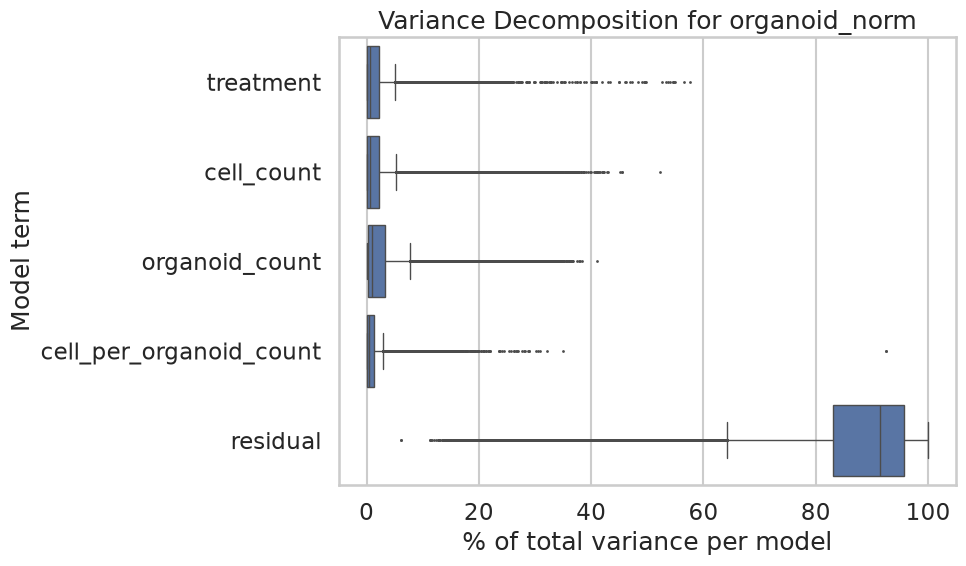

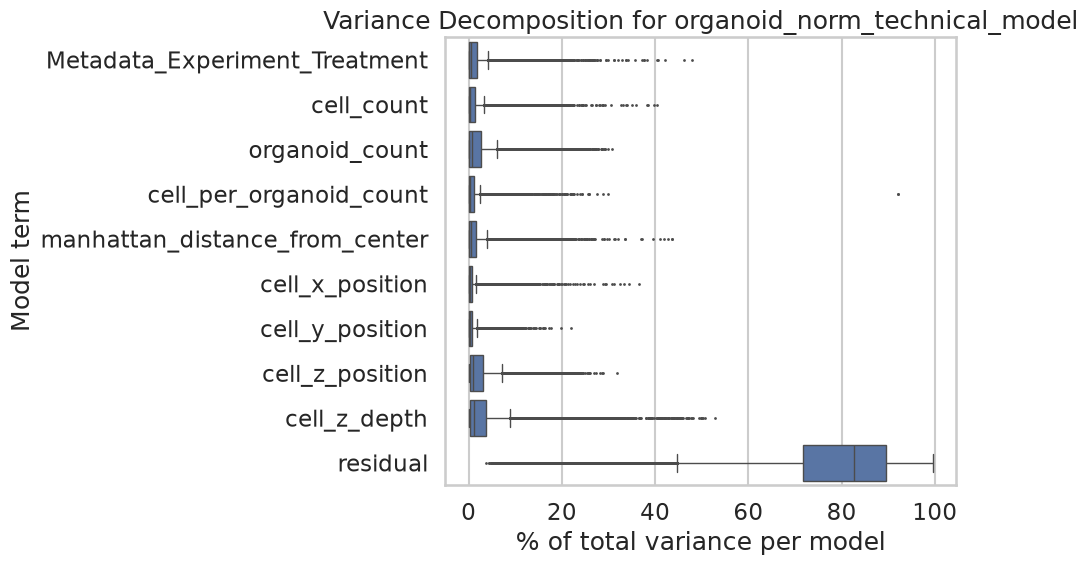

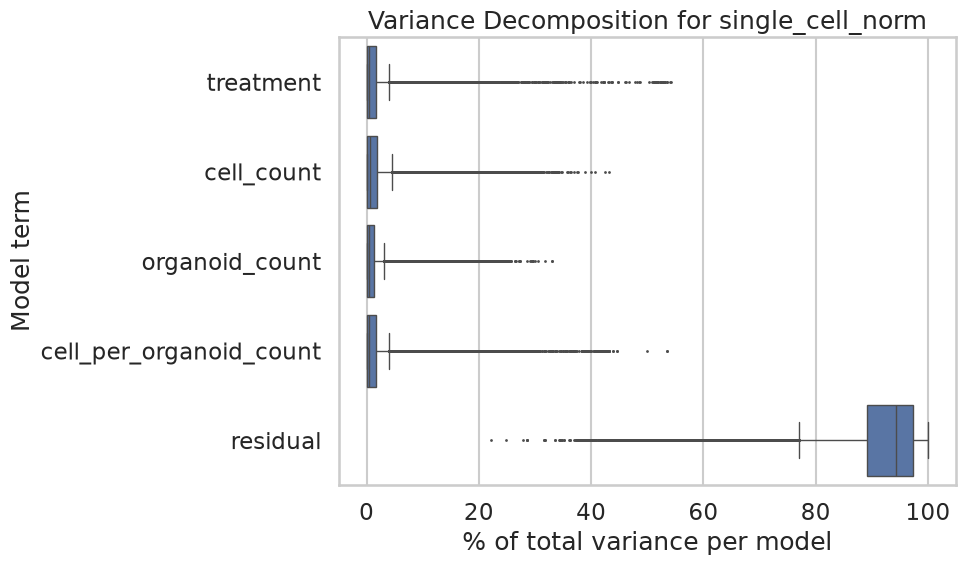

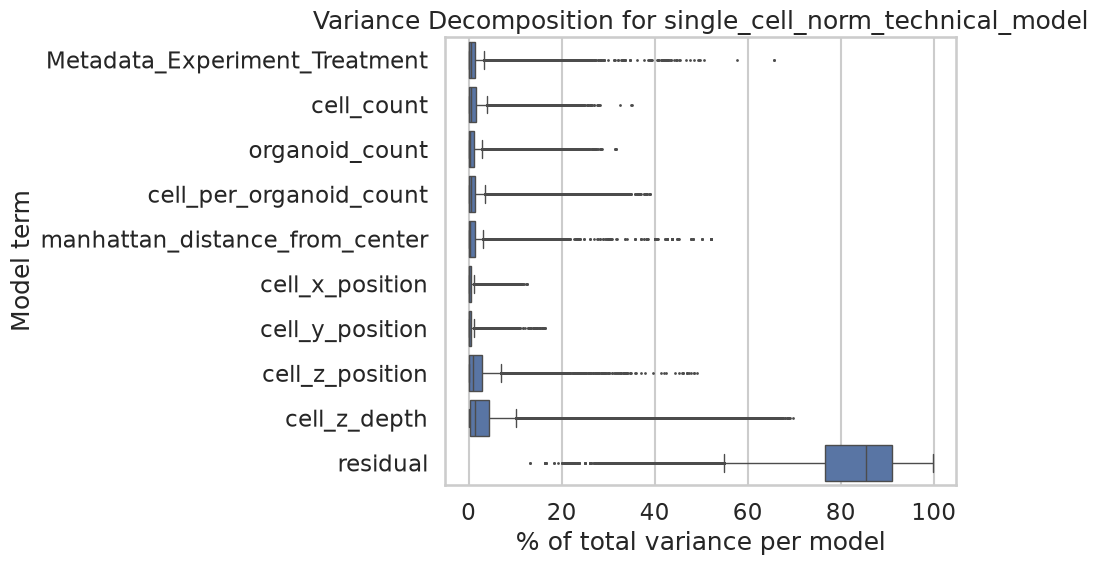

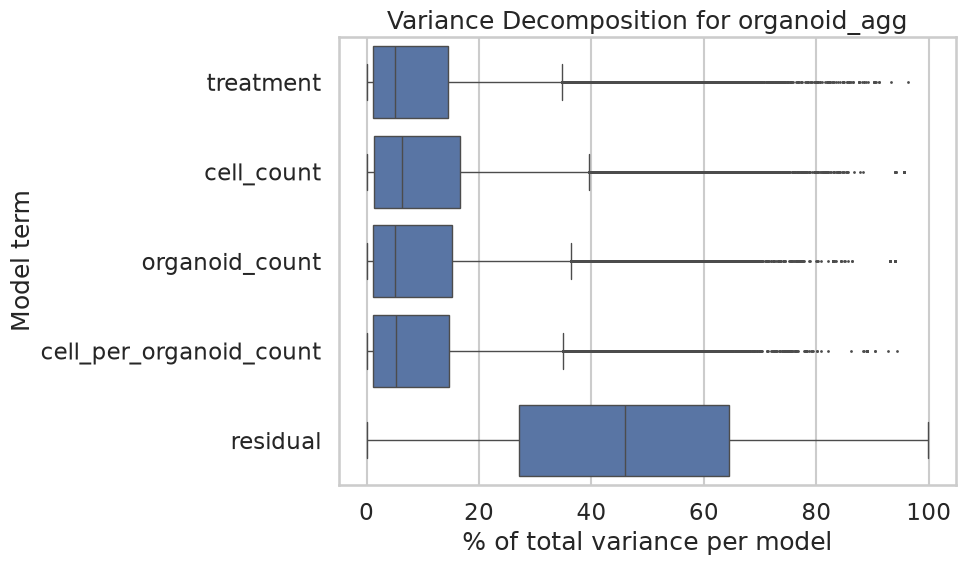

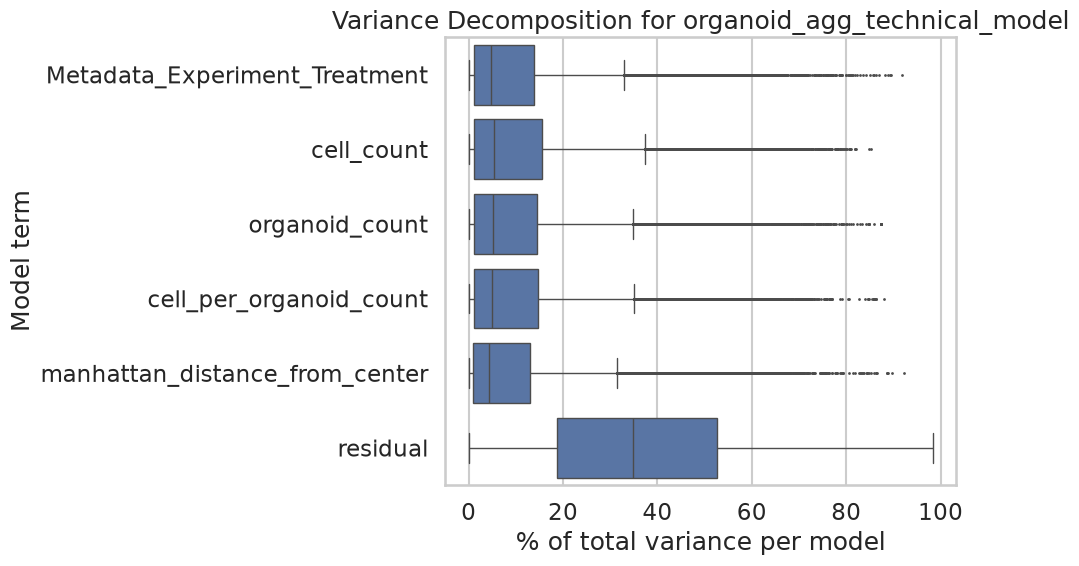

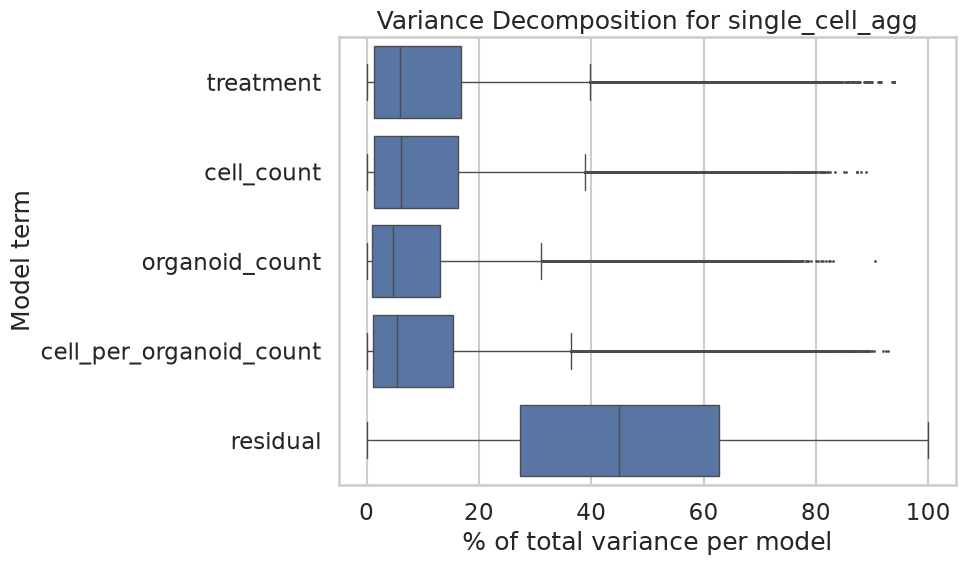

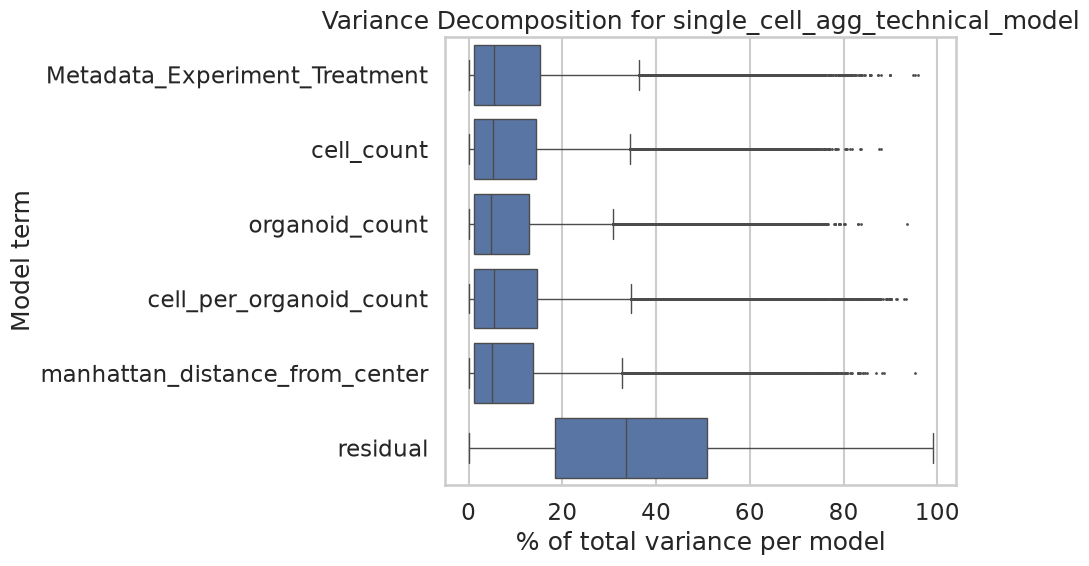

In [3]:
for lm_name, lm_dict in lm_results_dict.items():
    if not lm_dict["input_profile_path"].exists():
        print(f"skipping {lm_name}: {lm_dict['input_profile_path']} not found")
        continue
    df = pd.read_parquet(lm_dict["input_profile_path"])
    # one row per (fitted model, term): the share of that model's total variance
    var_decomp = df[["term", "term_pct_of_total_var"]].rename(
        columns={"term_pct_of_total_var": "pct_variance"}
    )
    # the residual is a property of the whole model (repeated on every term
    # row), so take it from one row per model rather than from a term row
    model_key = [
        c
        for c in [
            "patient",
            "Metadata_Biology_PatientTumor",
            "treatment",
            "Metadata_Experiment_Treatment",
            "feature",
        ]
        if c in df.columns
    ]
    residual = (
        df.drop_duplicates(model_key)[["residual_pct"]]
        .rename(columns={"residual_pct": "pct_variance"})
        .assign(term="residual")
    )
    var_decomp = pd.concat([var_decomp, residual], ignore_index=True)
    lm_dict["output_profile_path"].parent.mkdir(parents=True, exist_ok=True)
    var_decomp.to_parquet(lm_dict["output_profile_path"], index=False)
    plot_decomposed_variance(
        var_decomp,
        save_path=figures_path / "variance_decomposition.pdf",
    )

# 2. Residual diagnostics: why is the residual so high?

Questions, in order:

1. How is `residual_pct` distributed across models? Is a high mean driven by a few bad models or is it uniformly high?
2. Is it concentrated in particular feature families (compartment, channel, feature type)?
3. Is it concentrated in particular patients or treatments?
4. How much does adding the technical covariates (position, distance from center) actually reduce it? If barely, the missing variance is not explained by any of the modeled spatial/count terms.
5. Which technical covariates matter?

## 2.0 Load one row per fitted model

The fit statistics (`rsquared`, `residual_pct`) are repeated on every term
row of a model, so keep one row per (patient, treatment, feature).

In [4]:
model_dfs = []
for name, (file_name, profile, model_type) in lm_files.items():
    if not (lm_results_path / file_name).exists():
        print(f"skipping {name}: {file_name} not found")
        continue
    df = pd.read_parquet(lm_results_path / file_name).rename(columns=rename_map)
    # the technical model repeats the treatment term name in the `term` column;
    # the fit statistics are identical across a model's rows either way
    per_model = df.drop_duplicates(model_keys)[
        model_keys
        + [
            "rsquared",
            "residual_pct",
            "Compartment",
            "Channel",
            "Feature_type",
            "Measurement",
        ]
    ].copy()
    per_model["model_name"] = name
    per_model["profile"] = profile
    per_model["model_type"] = model_type
    model_dfs.append(per_model)
    print(f"{name}: {per_model.shape[0]} models")

models = pd.concat(model_dfs, ignore_index=True)
models["Channel"] = models["Channel"].fillna("NoChannel")
models["Compartment"] = models["Compartment"].fillna("adjacent")
models.head()

organoid_norm: 45034 models
organoid_norm_technical_model: 45034 models
single_cell_norm: 135102 models
single_cell_norm_technical_model: 135102 models
organoid_agg: 45034 models
organoid_agg_technical_model: 45034 models
single_cell_agg: 135102 models
single_cell_agg_technical_model: 135102 models


,patient,treatment,feature,rsquared,residual_pct,Compartment,Channel,Feature_type,Measurement,model_name,profile,model_type
0,NF0014_T1,Trametinib_1uM,Organoid_AGP_Granularity_1,0.210990,78.901018,Organoid,AGP,Granularity,1,organoid_norm,organoid,base
1,NF0014_T1,Trametinib_1uM,Organoid_AGP_Granularity_10,0.506807,49.319316,Organoid,AGP,Granularity,10,organoid_norm,organoid,base
2,NF0014_T1,Trametinib_1uM,Organoid_AGP_Granularity_11,0.136355,86.364504,Organoid,AGP,Granularity,11,organoid_norm,organoid,base
3,NF0014_T1,Trametinib_1uM,Organoid_AGP_Granularity_12,0.337062,66.293770,Organoid,AGP,Granularity,12,organoid_norm,organoid,base
4,NF0014_T1,Trametinib_1uM,Organoid_AGP_Granularity_13,0.252401,74.759925,Organoid,AGP,Granularity,13,organoid_norm,organoid,base


## 2.1 Distribution of `residual_pct`

If the mean is high because of a long tail of near-100% models, the fix is
different than if the whole distribution sits at 80-90%.

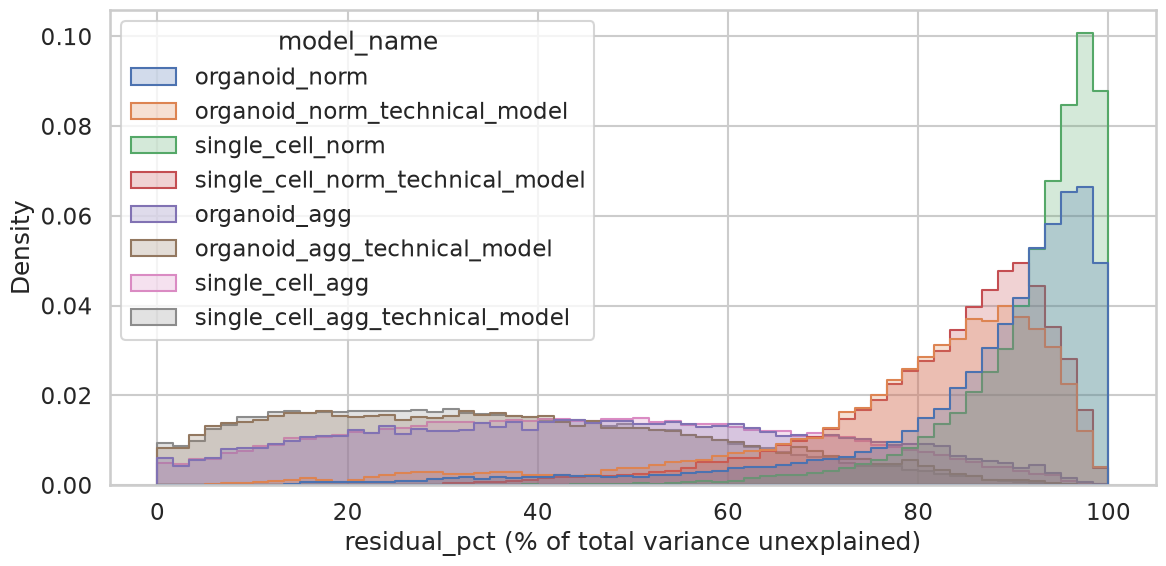

In [5]:
summary = models.groupby("model_name")["residual_pct"].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
)
for cutoff in (80, 90, 95, 99):
    summary[f"frac_>{cutoff}%"] = models.groupby("model_name")["residual_pct"].apply(
        lambda s, c=cutoff: (s > c).mean()
    )
summary.reset_index().to_parquet(residual_results_path / "residual_pct_summary.parquet")

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    data=models,
    x="residual_pct",
    hue="model_name",
    bins=60,
    element="step",
    stat="density",
    common_norm=False,
    ax=ax,
)
ax.set_xlabel("residual_pct (% of total variance unexplained)")
fig.tight_layout()
pdfs.savefig(fig, residual_figures_path / "residual_diagnostics.pdf")
plt.show()

# 3. Models where the variates outperform the residual

A fitted model (feature x patient x treatment) "wins" when the variance explained by all its variates together exceeds the residual variance, i.e. `residual_pct < 50`. A term "wins" individually when its own share of total variance exceeds the residual share.

In [6]:
win_summary = []
for lm_name, lm_dict in lm_results_dict.items():
    if not lm_dict["input_profile_path"].exists():
        print(f"skipping {lm_name}: {lm_dict['input_profile_path']} not found")
        continue
    df = pd.read_parquet(lm_dict["input_profile_path"])
    # explained vs residual variance is a property of the whole model
    # (repeated on every term row), so compare on the term rows directly:
    # the model-level explained share is 100 - residual_pct
    df["explained_all_pct"] = 100 - df["residual_pct"]
    df["variates_beat_residual"] = df["explained_all_pct"] > df["residual_pct"]
    df["term_beats_residual"] = df["term_pct_of_total_var"] > df["residual_pct"]

    model_key = [
        c
        for c in [
            "patient",
            "Metadata_Biology_PatientTumor",
            "treatment",
            "Metadata_Experiment_Treatment",
            "feature",
        ]
        if c in df.columns
    ]
    models_df = df.drop_duplicates(model_key)
    winners = models_df.loc[models_df["variates_beat_residual"]]
    print(
        f"{lm_name}: {len(winners)} / {len(models_df)} models "
        f"({len(winners) / len(models_df):.1%}) have variates > residual"
    )
    # terms that individually explain more variance than the residual
    term_wins = (
        df.groupby("term")["term_beats_residual"]
        .agg(n_wins="sum", frac_wins="mean")
        .sort_values("n_wins", ascending=False)
    )
    print(term_wins.round(3))
    winners.to_parquet(
        win_dir / f"{lm_name}_variates_beat_residual.parquet", index=False
    )
    win_summary.append(
        pd.DataFrame(
            {
                "model_name": [lm_name],
                "n_models": [len(models_df)],
                "n_variates_beat_residual": [len(winners)],
                "frac_variates_beat_residual": [len(winners) / len(models_df)],
            }
        )
    )

win_summary = pd.concat(win_summary, ignore_index=True)
win_summary.to_parquet(win_dir / "variates_beat_residual_summary.parquet", index=False)
win_summary

organoid_norm: 2211 / 45034 models (4.9%) have variates > residual
                         n_wins  frac_wins
term                                      
cell_count                  283      0.006
treatment                    19      0.000
cell_per_organoid_count       2      0.000
organoid_count                0      0.000
organoid_norm_technical_model: 3992 / 45034 models (8.9%) have variates > residual
                                n_wins  frac_wins
term                                             
cell_z_depth                       160      0.004
cell_count                          16      0.000
Metadata_Experiment_Treatment       13      0.000
manhattan_distance_from_center       7      0.000
cell_per_organoid_count              2      0.000
cell_y_position                      0      0.000
cell_x_position                      0      0.000
cell_z_position                      0      0.000
organoid_count                       0      0.000
single_cell_norm: 410 / 135102 models (0.3

,model_name,n_models,n_variates_beat_residual,frac_variates_beat_residual
0,organoid_norm,45034,2211,0.049096
1,organoid_norm_technical_model,45034,3992,0.088644
2,single_cell_norm,135102,410,0.003035
3,single_cell_norm_technical_model,135102,3669,0.027157
4,organoid_agg,45034,22400,0.497402
5,organoid_agg_technical_model,45034,28852,0.640671
6,single_cell_agg,135102,70215,0.519718
7,single_cell_agg_technical_model,135102,90405,0.669161


# 4. The highest-explained models: which features and variates?

For each LM the models with the largest explained variance (lowest `residual_pct`) are ranked. The top few are drawn as stacked variance decompositions; the larger top set is used to count which variate dominates each model and which feature families (compartment, channel, feature type) they come from.

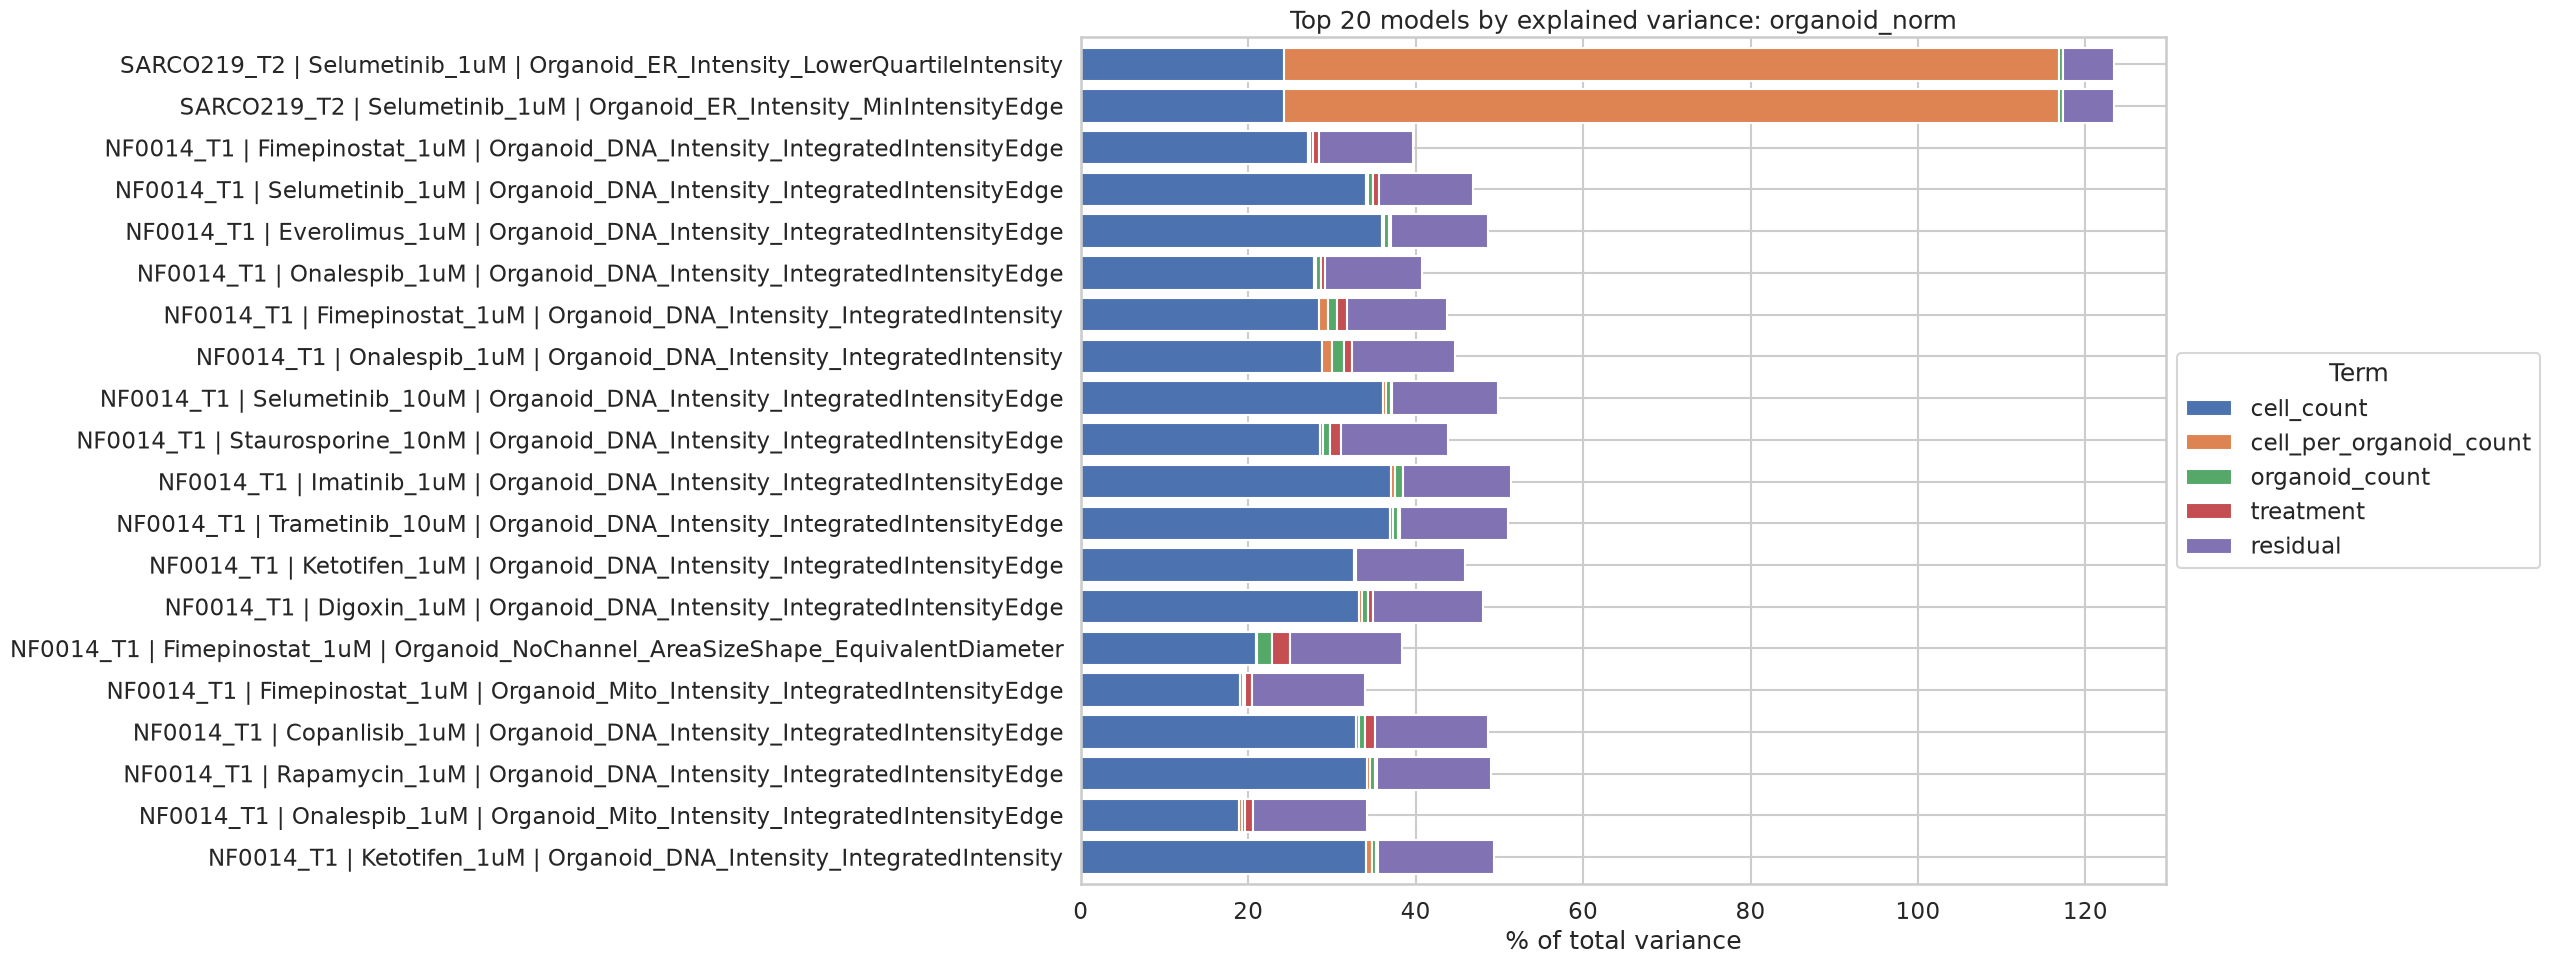

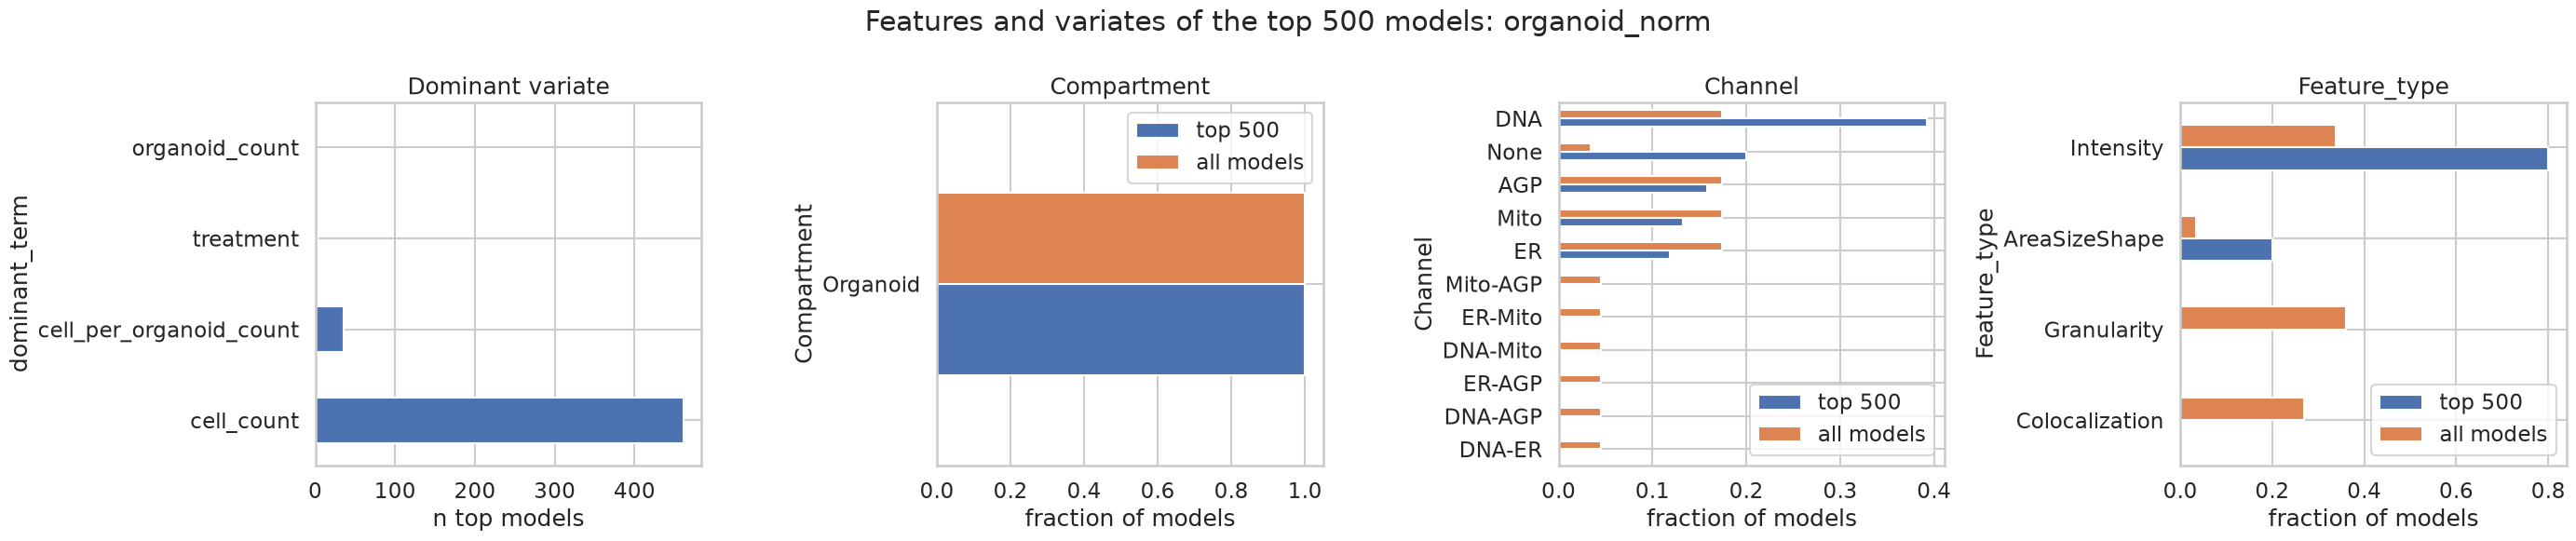

organoid_norm
    patient         treatment                                       feature           dominant_term  residual_pct
SARCO219_T2   Selumetinib_1uM  Organoid_ER_Intensity_LowerQuartileIntensity cell_per_organoid_count      6.099895
SARCO219_T2   Selumetinib_1uM        Organoid_ER_Intensity_MinIntensityEdge cell_per_organoid_count      6.099895
  NF0016_T1    Copanlisib_1uM Organoid_ER_Intensity_IntegratedIntensityEdge              cell_count     26.070080
  NF0014_T1  Mirdametinib_1uM        Organoid_DNA_Intensity_MedianIntensity              cell_count     21.132631
  NF0014_T1 Mirdametinib_10uM        Organoid_DNA_Intensity_MedianIntensity              cell_count     25.442805
  NF0014_T1    Everolimus_1uM        Organoid_DNA_Intensity_MedianIntensity              cell_count     20.052712
  NF0014_T1  Binimetinib_10uM        Organoid_DNA_Intensity_MedianIntensity              cell_count     24.375406
  NF0014_T1  Mirdametinib_1uM Organoid_DNA_Intensity_LowerQuartileIntensit

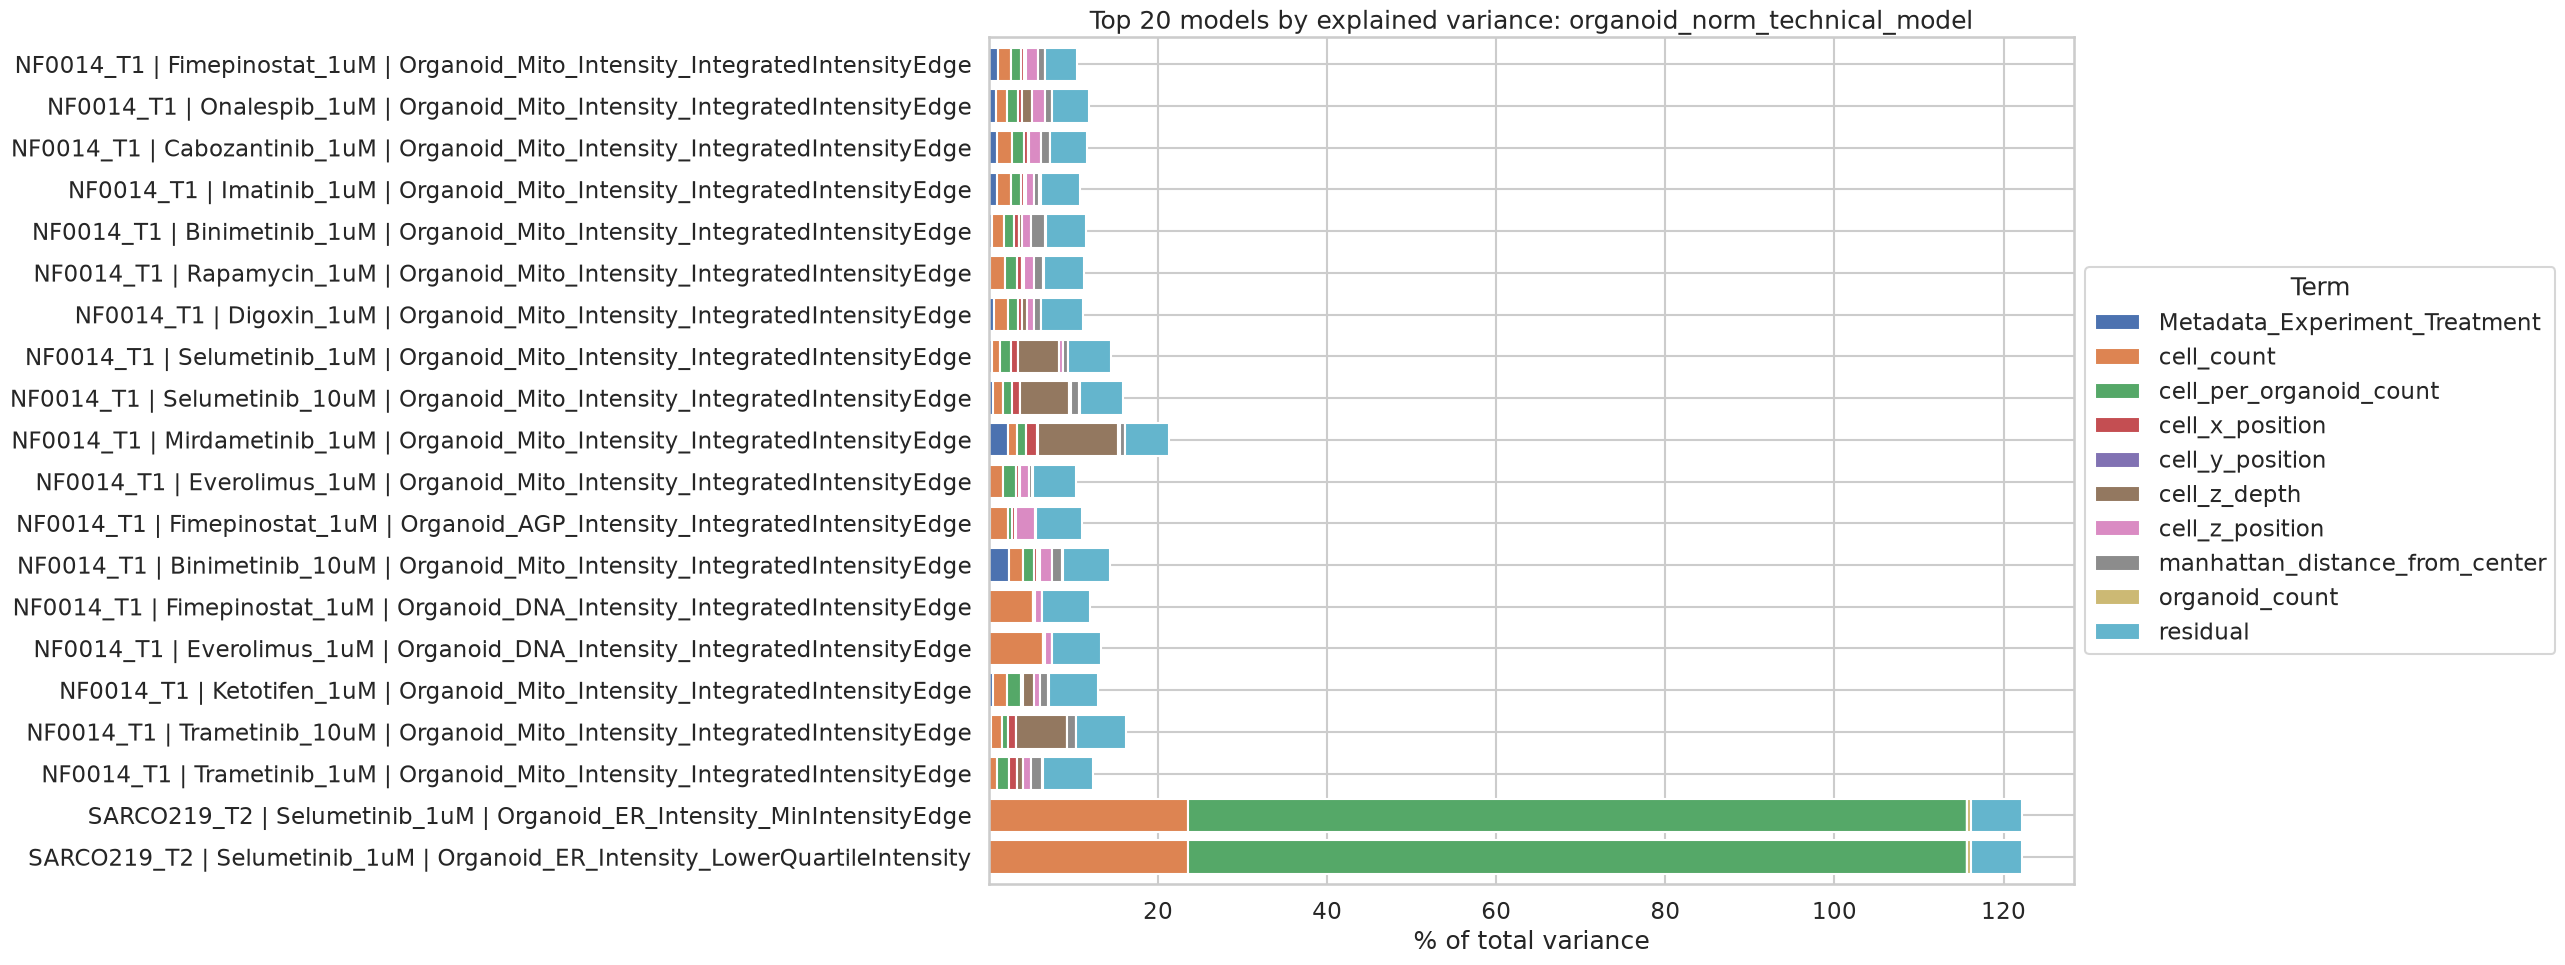

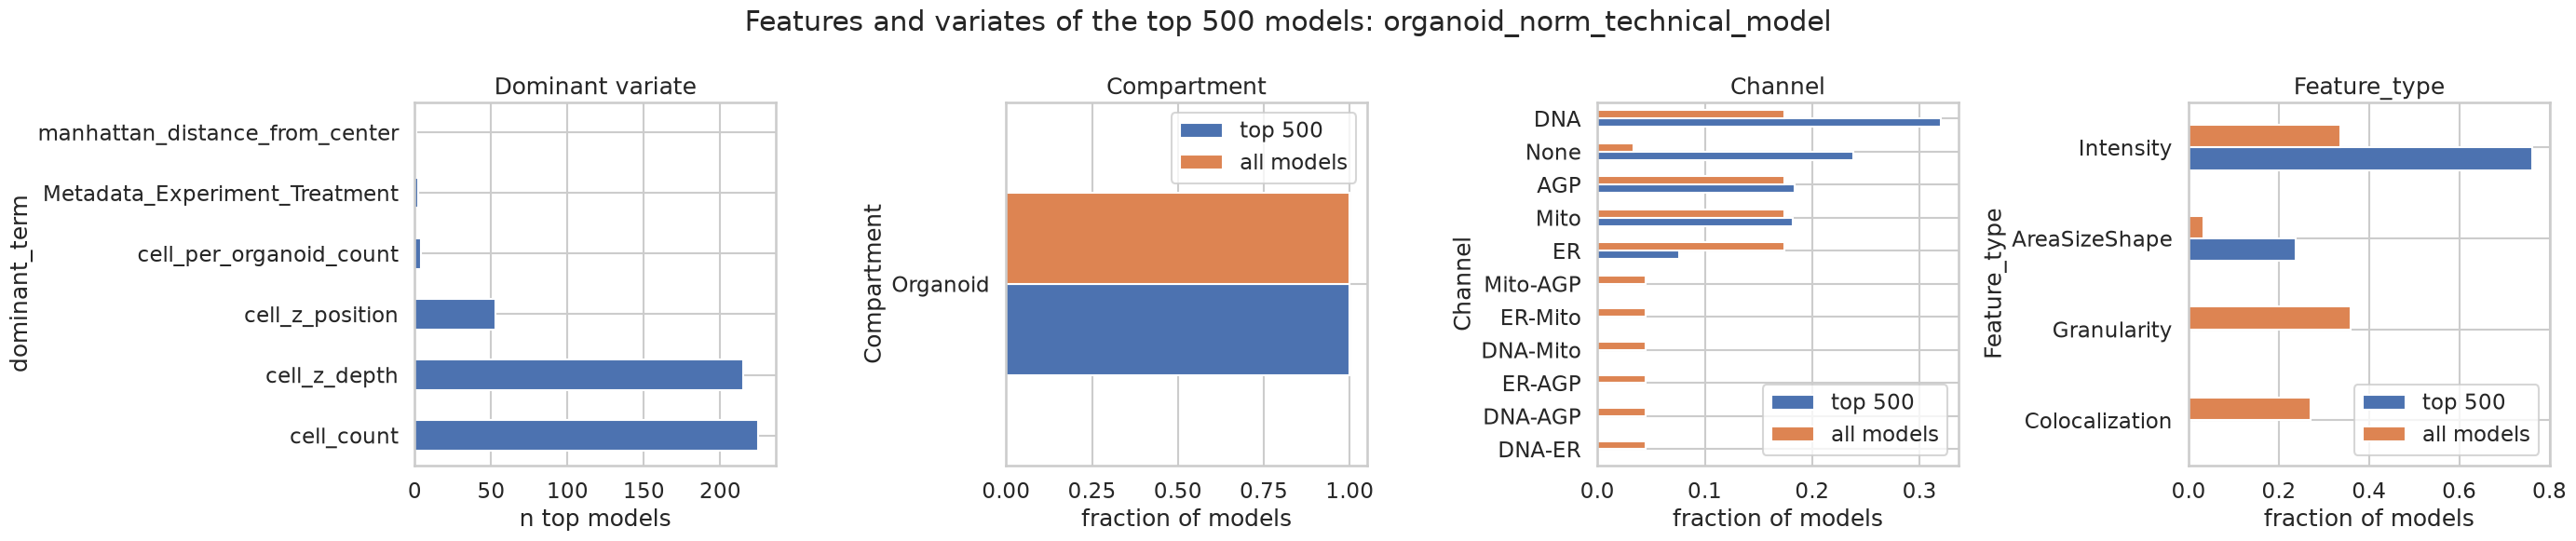

organoid_norm_technical_model
    patient        treatment                                         feature           dominant_term  residual_pct
SARCO219_T2  Selumetinib_1uM          Organoid_ER_Intensity_MinIntensityEdge cell_per_organoid_count      6.067223
SARCO219_T2  Selumetinib_1uM    Organoid_ER_Intensity_LowerQuartileIntensity cell_per_organoid_count      6.067223
  NF0018_T6    Rapamycin_1uM  Organoid_AGP_Intensity_IntegratedIntensityEdge            cell_z_depth     18.035818
  NF0018_T6  Trametinib_10uM  Organoid_AGP_Intensity_IntegratedIntensityEdge            cell_z_depth     16.303877
  NF0018_T6 Selumetinib_10uM  Organoid_AGP_Intensity_IntegratedIntensityEdge            cell_z_depth     17.092293
  NF0018_T6 Fimepinostat_1uM  Organoid_AGP_Intensity_IntegratedIntensityEdge            cell_z_depth     17.121452
  NF0018_T6   Linsitinib_1uM Organoid_Mito_Intensity_IntegratedIntensityEdge            cell_z_depth     15.470802
  NF0018_T6    Rapamycin_1uM Organoid_Mito_Intensi

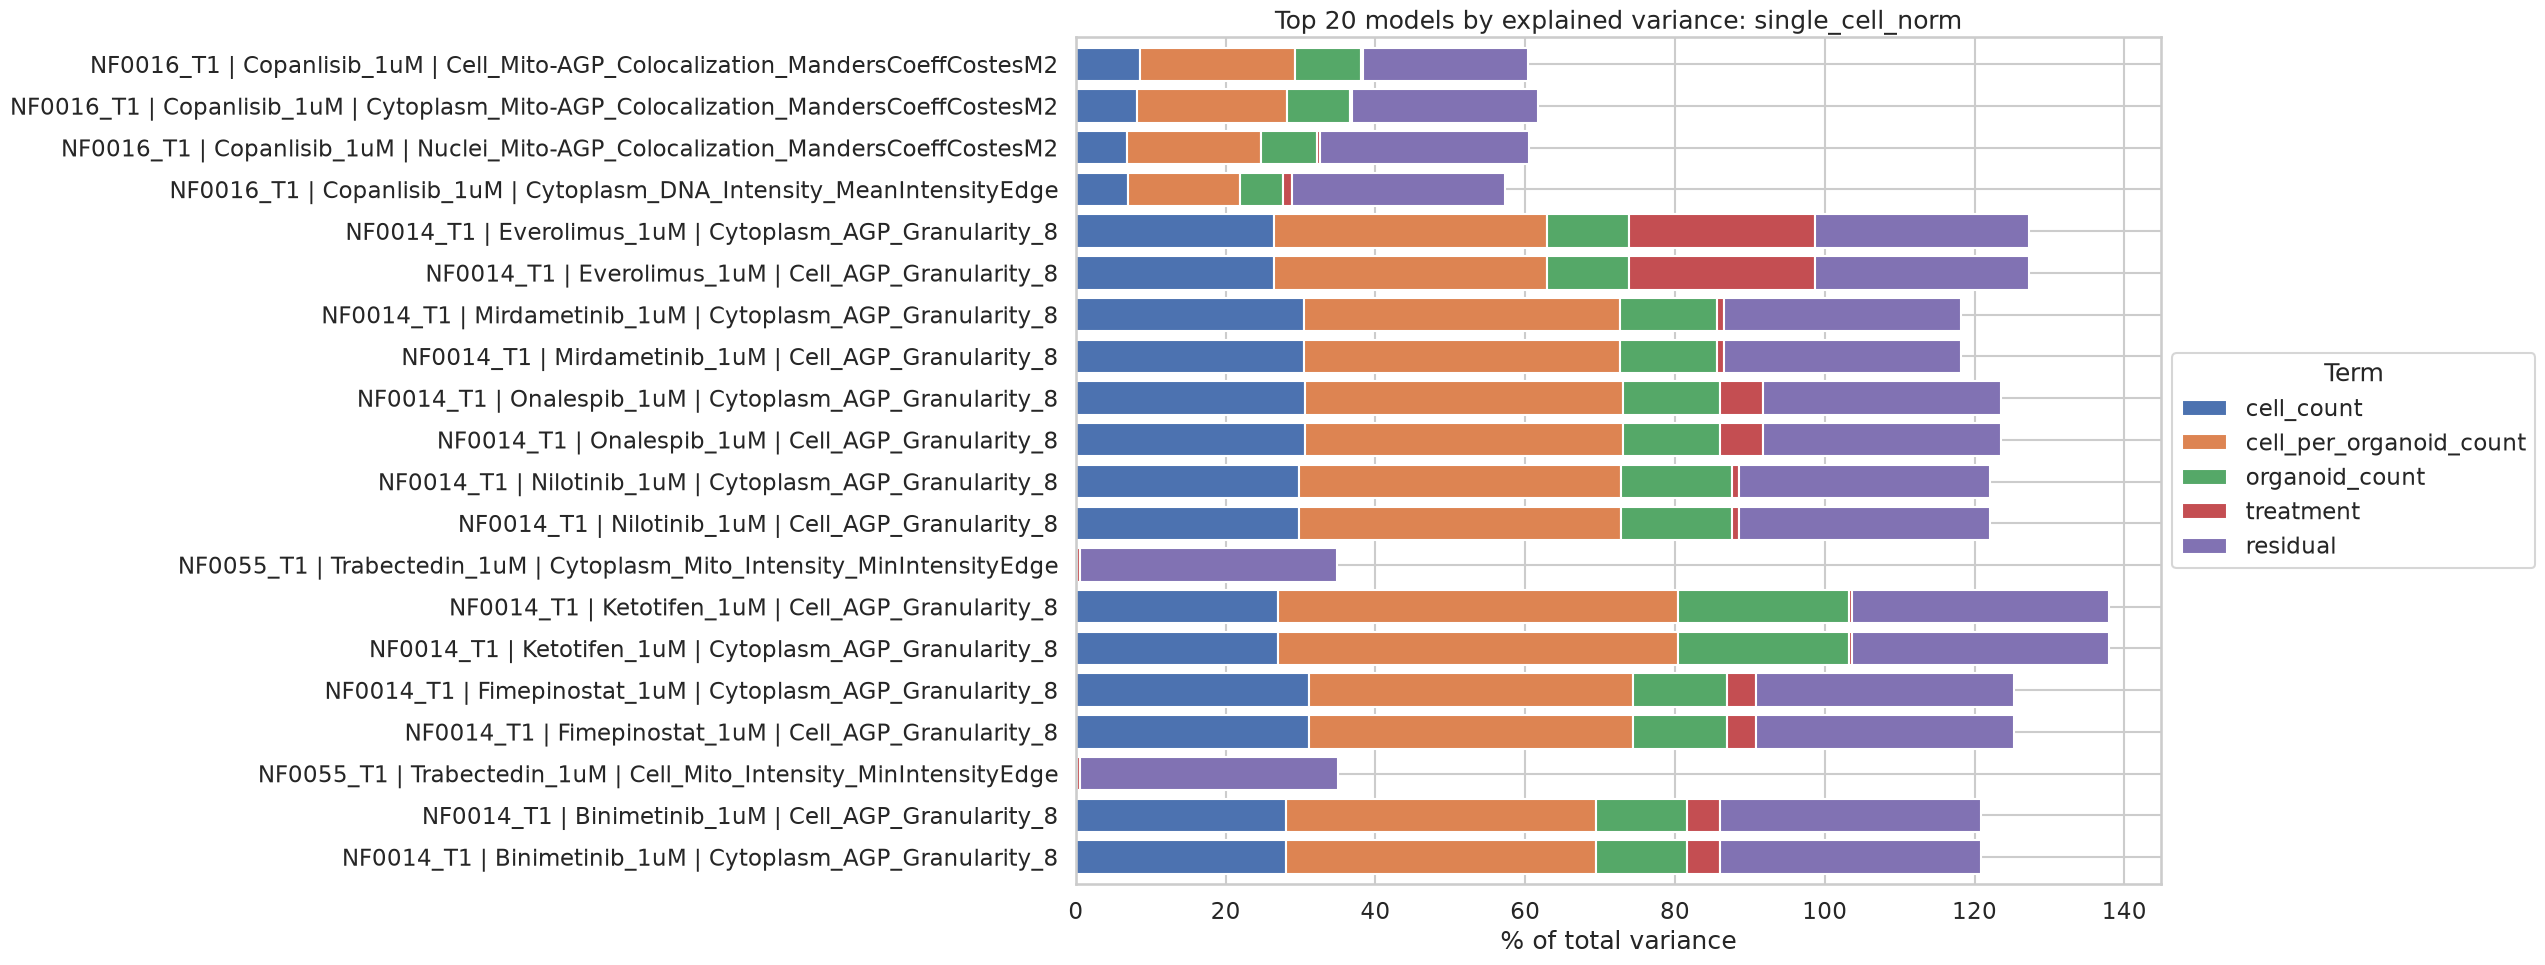

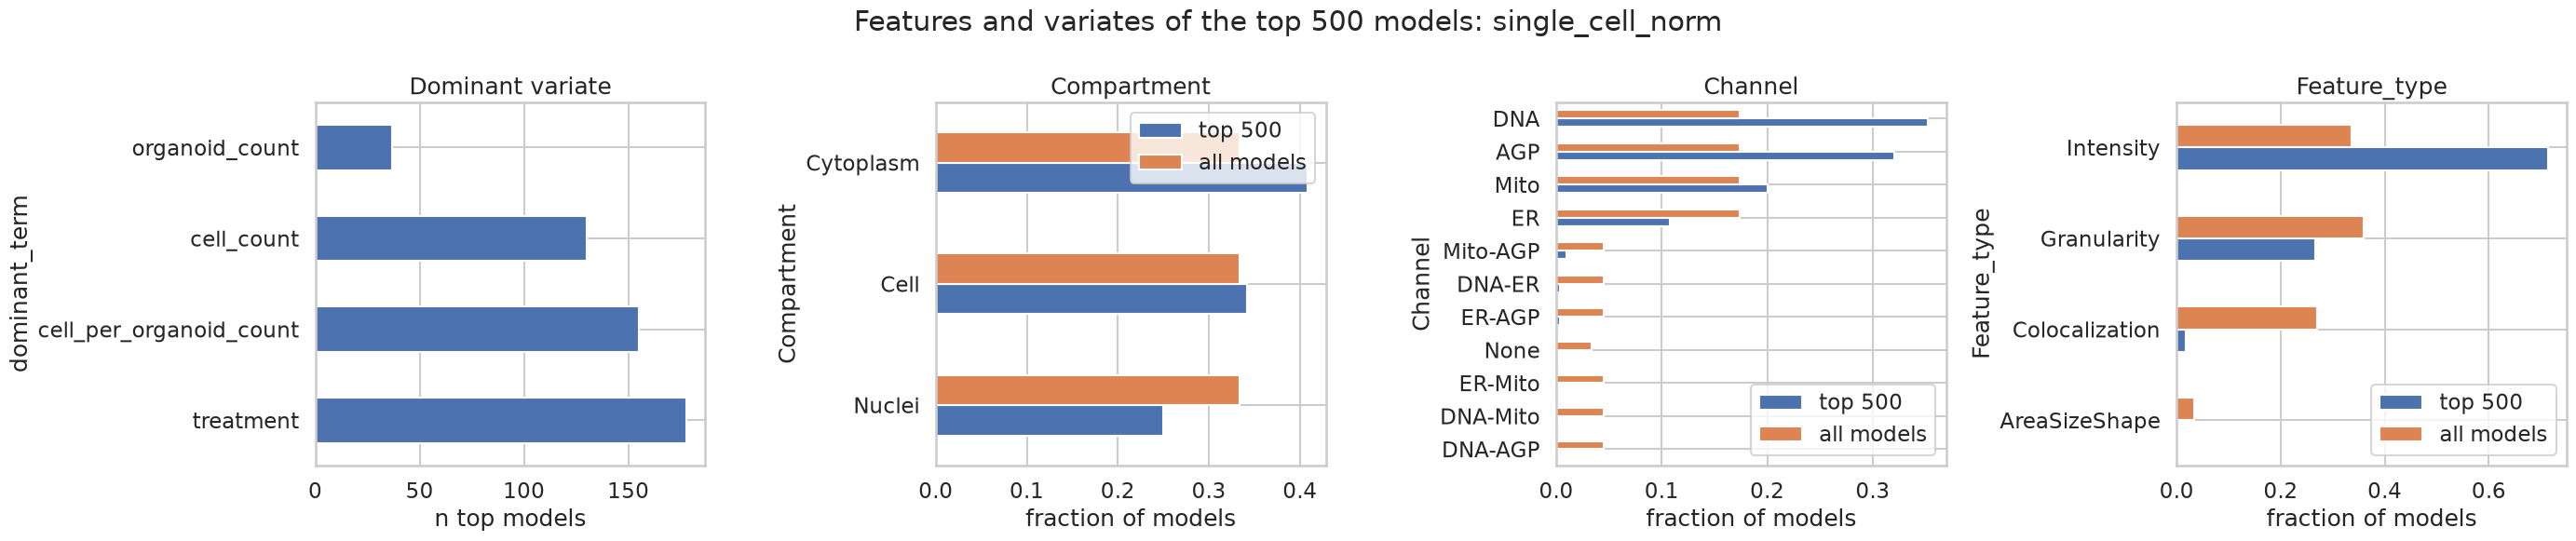

single_cell_norm
  patient       treatment                                       feature           dominant_term  residual_pct
NF0014_T1 Trametinib_10uM               Cell_ER_Intensity_MeanIntensity               treatment     40.295711
NF0014_T1 Trametinib_10uM          Cytoplasm_ER_Intensity_MeanIntensity               treatment     40.206713
NF0014_T1 Trametinib_10uM           Cell_ER_Intensity_MeanIntensityEdge               treatment     40.717406
NF0014_T1   Ketotifen_1uM                        Cell_AGP_Granularity_8 cell_per_organoid_count     34.376085
NF0014_T1   Ketotifen_1uM                   Cytoplasm_AGP_Granularity_8 cell_per_organoid_count     34.376085
NF0014_T1 Trametinib_10uM      Cell_ER_Intensity_LowerQuartileIntensity               treatment     40.803032
NF0014_T1 Trametinib_10uM Cytoplasm_ER_Intensity_LowerQuartileIntensity               treatment     42.154279
NF0014_T1 Trametinib_10uM      Cytoplasm_ER_Intensity_MeanIntensityEdge               treatment     40.

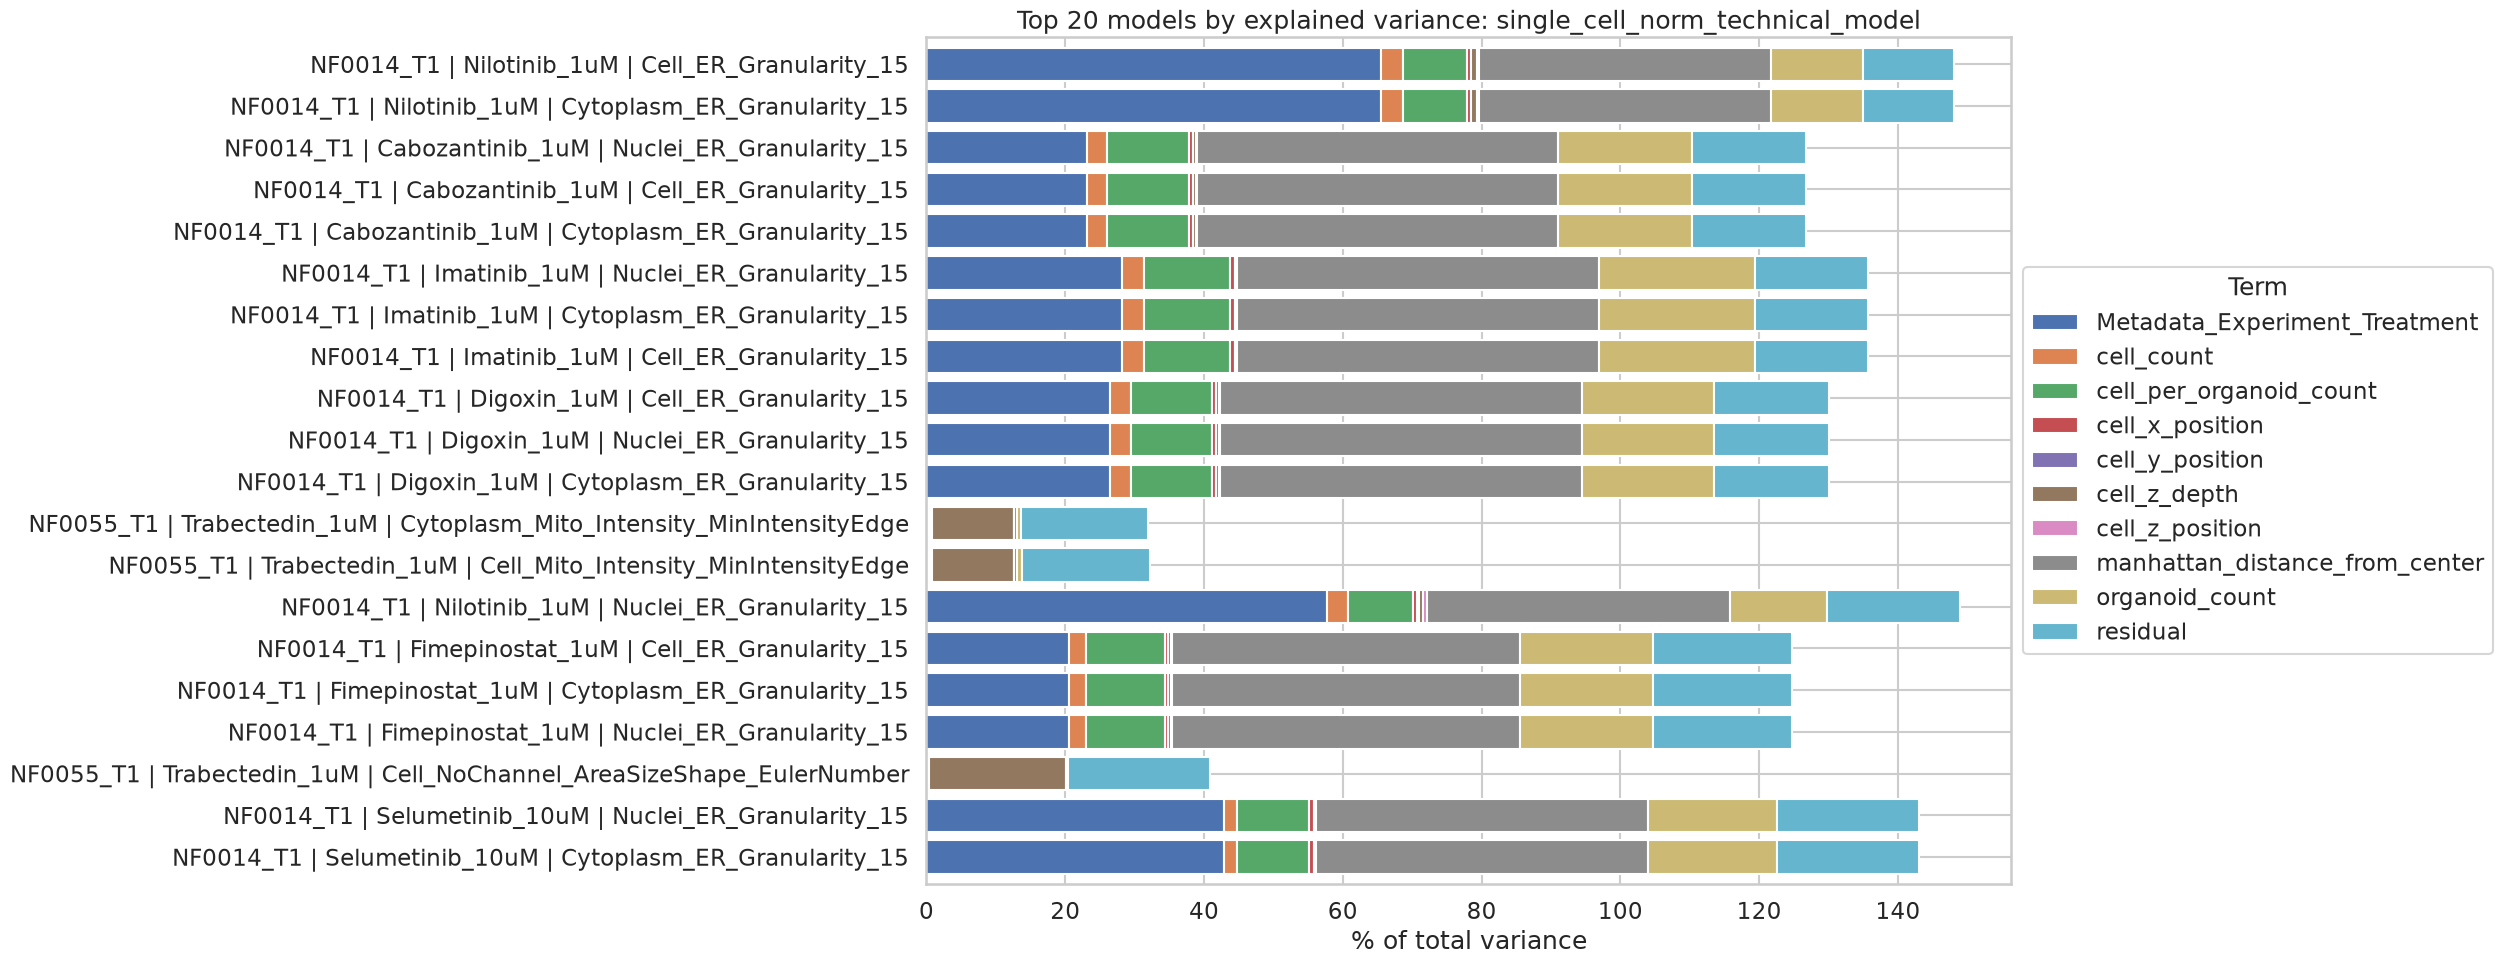

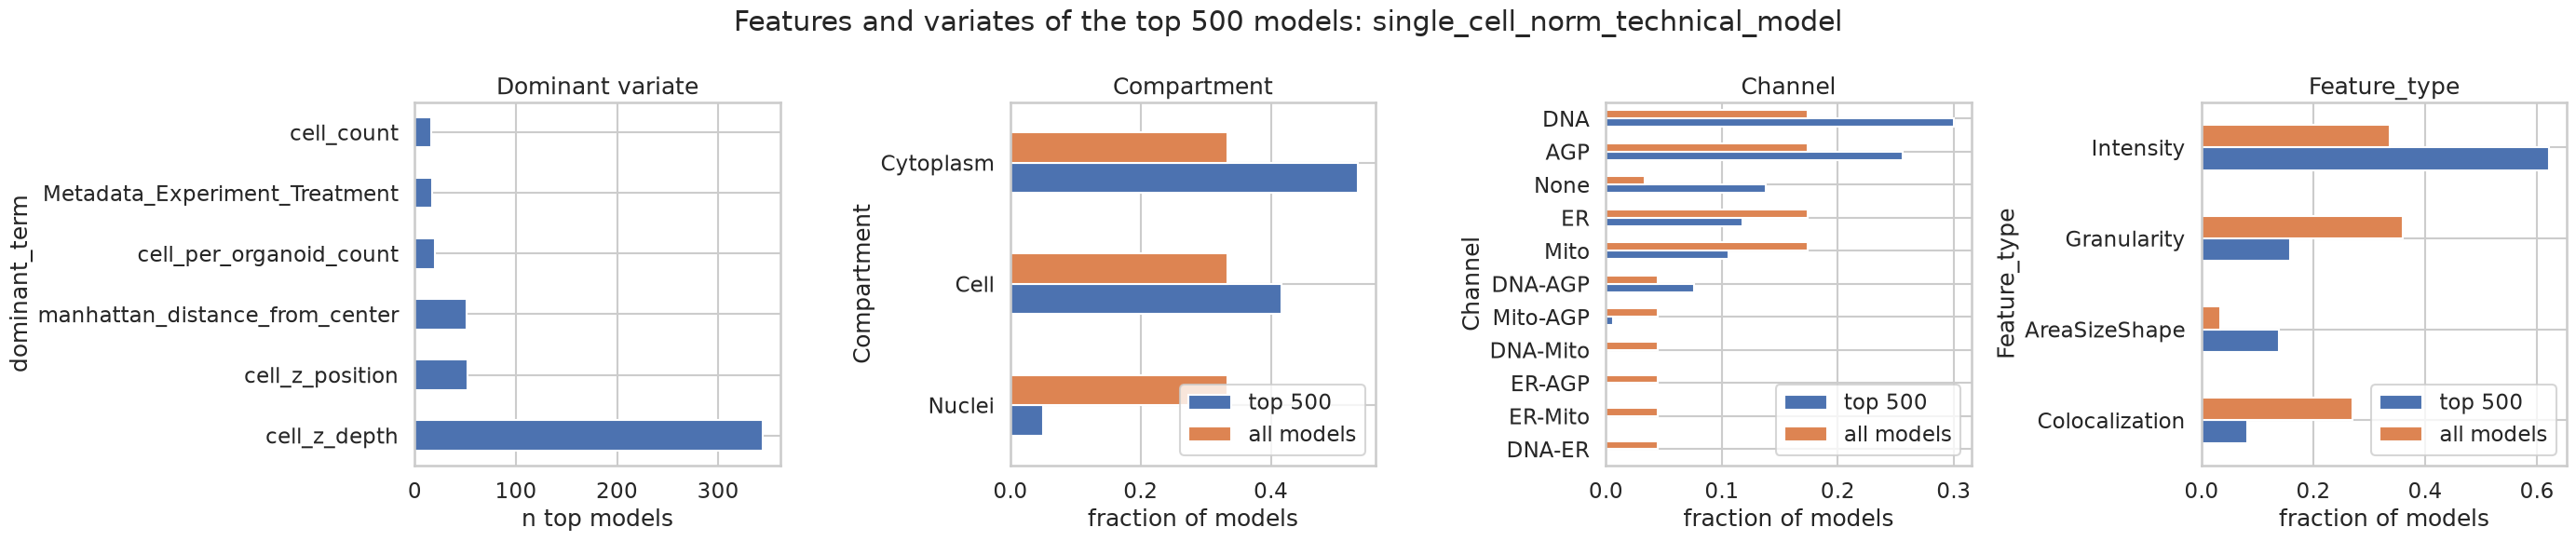

single_cell_norm_technical_model
  patient         treatment                                              feature dominant_term  residual_pct
NF0037_T1  Selumetinib_10uM Cytoplasm_NoChannel_AreaSizeShape_EquivalentDiameter  cell_z_depth     29.259998
NF0037_T1  Fimepinostat_1uM Cytoplasm_NoChannel_AreaSizeShape_EquivalentDiameter  cell_z_depth     30.085021
NF0037_T1  Sapanisertib_1uM Cytoplasm_NoChannel_AreaSizeShape_EquivalentDiameter  cell_z_depth     30.270432
NF0037_T1    Copanlisib_1uM Cytoplasm_NoChannel_AreaSizeShape_EquivalentDiameter  cell_z_depth     30.555129
NF0037_T1     Nilotinib_1uM Cytoplasm_NoChannel_AreaSizeShape_EquivalentDiameter  cell_z_depth     30.155166
NF0037_T1     Onalespib_1uM Cytoplasm_NoChannel_AreaSizeShape_EquivalentDiameter  cell_z_depth     30.671102
NF0037_T1 Mirdametinib_10uM Cytoplasm_NoChannel_AreaSizeShape_EquivalentDiameter  cell_z_depth     29.420782
NF0037_T1   Selumetinib_1uM Cytoplasm_NoChannel_AreaSizeShape_EquivalentDiameter  cell_z_depth 

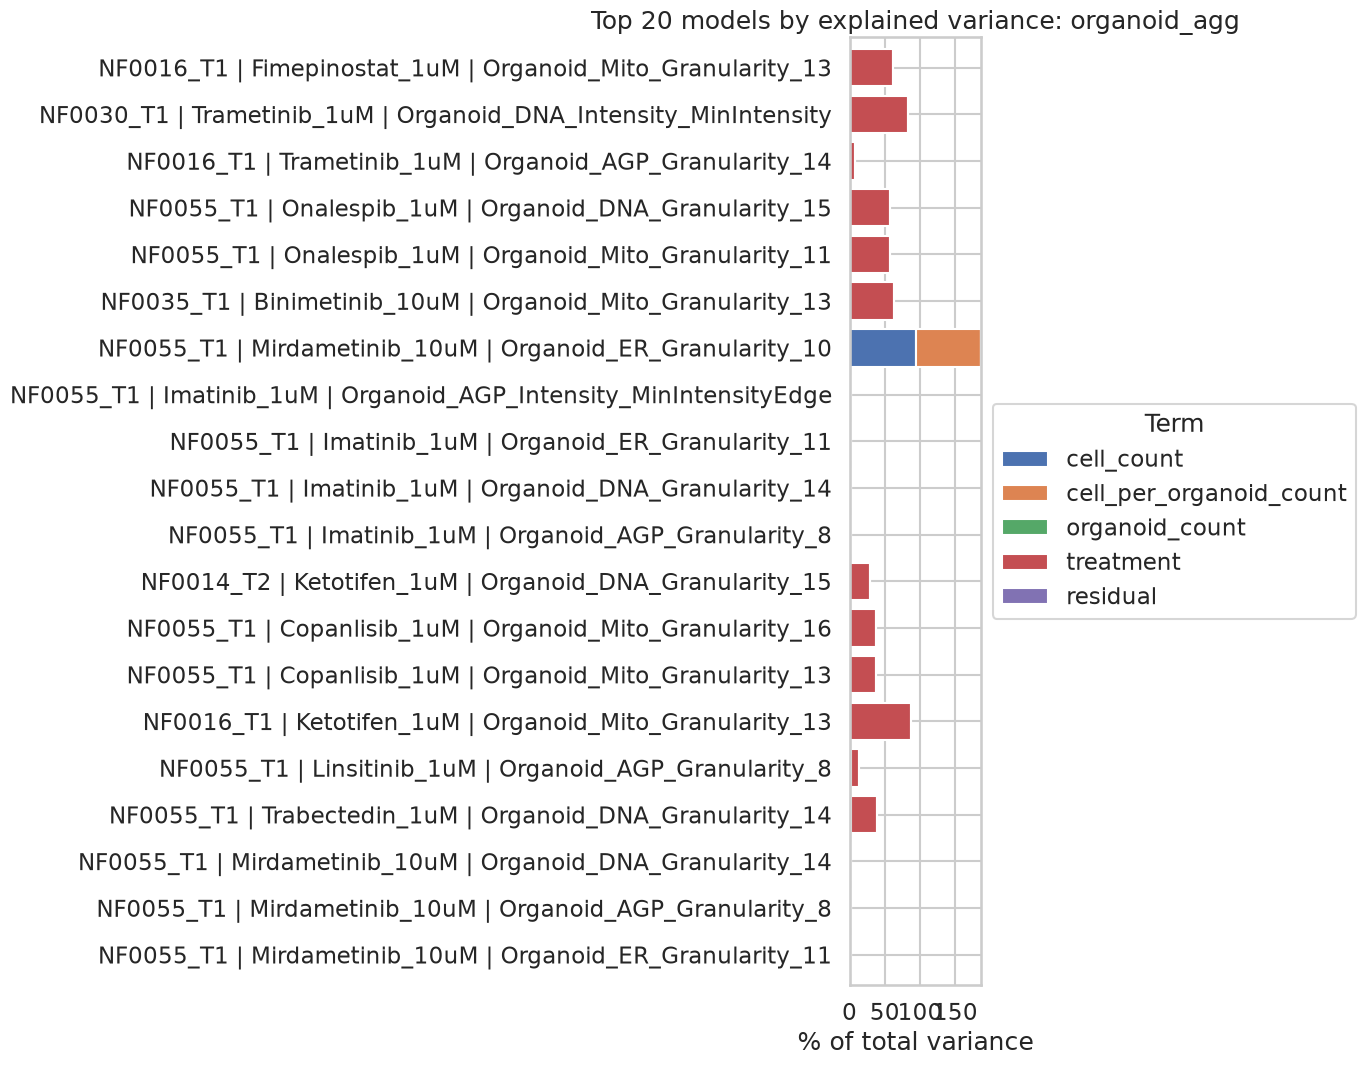

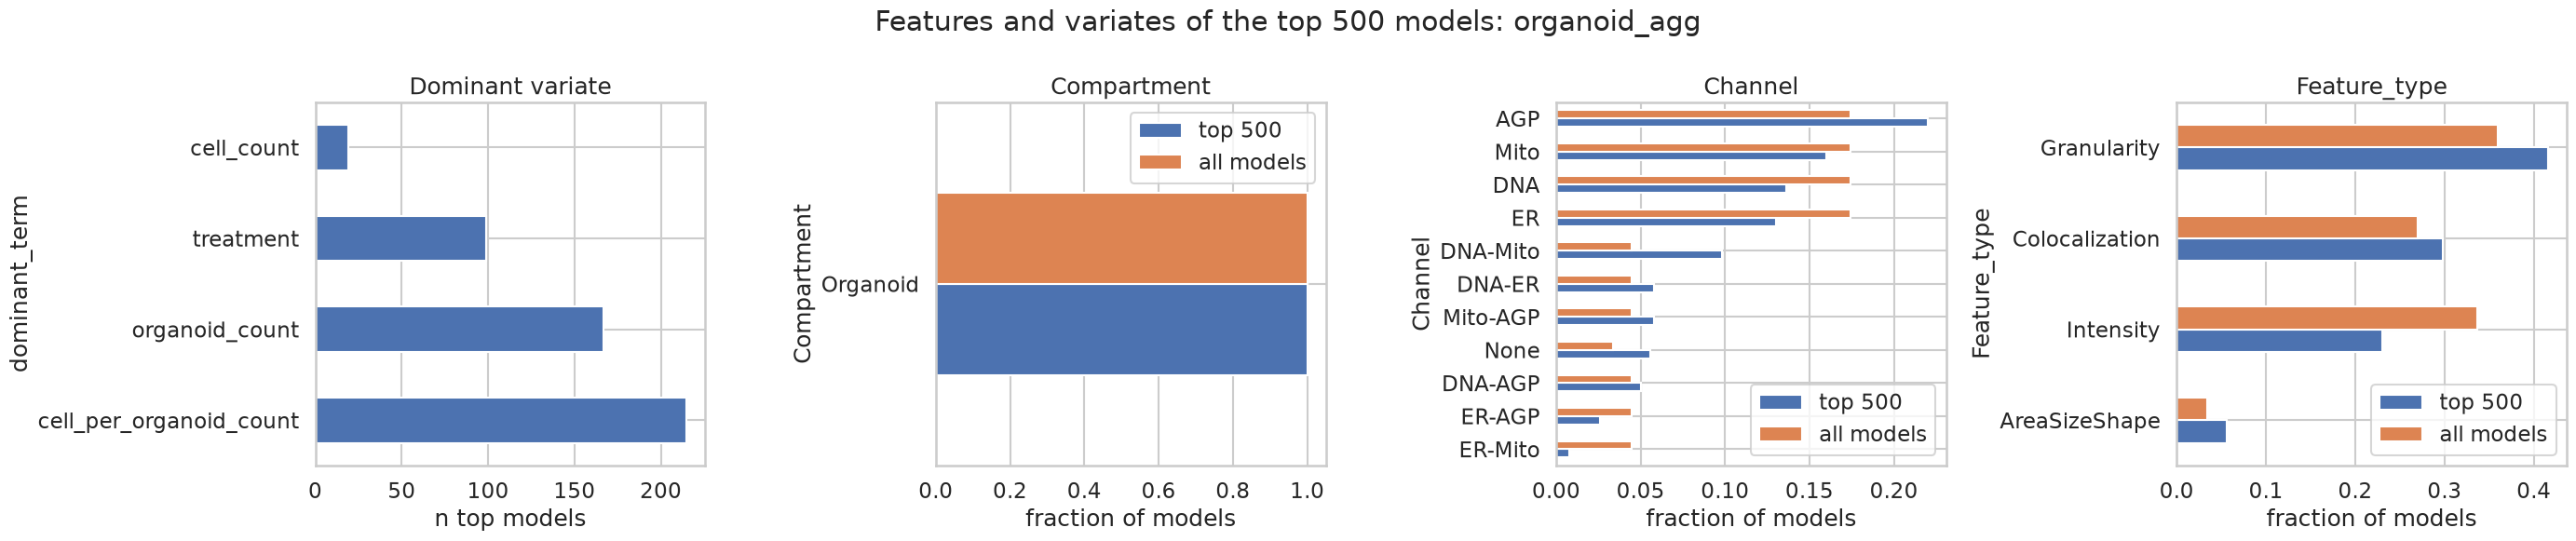

organoid_agg
  patient       treatment                            feature dominant_term  residual_pct
NF0014_T1 Binimetinib_1uM Organoid_ER_Intensity_MaxIntensity     treatment  1.237600e+00
NF0055_T1   Nilotinib_1uM         Organoid_ER_Granularity_10    cell_count  4.172398e-27
NF0055_T1   Nilotinib_1uM       Organoid_Mito_Granularity_14    cell_count  4.172398e-27
NF0055_T1  Linsitinib_1uM       Organoid_Mito_Granularity_14    cell_count  1.608014e-26
NF0055_T1  Linsitinib_1uM         Organoid_ER_Granularity_10    cell_count  1.608014e-26
NF0055_T1 Trabectedin_1uM         Organoid_ER_Granularity_10    cell_count  4.006512e-27
NF0055_T1    Imatinib_1uM       Organoid_Mito_Granularity_14    cell_count  4.121911e-27
NF0055_T1    Imatinib_1uM         Organoid_ER_Granularity_10    cell_count  4.121911e-27
NF0055_T1 Trabectedin_1uM       Organoid_Mito_Granularity_14    cell_count  4.006512e-27
NF0055_T1   Onalespib_1uM       Organoid_Mito_Granularity_14    cell_count  4.572689e-27


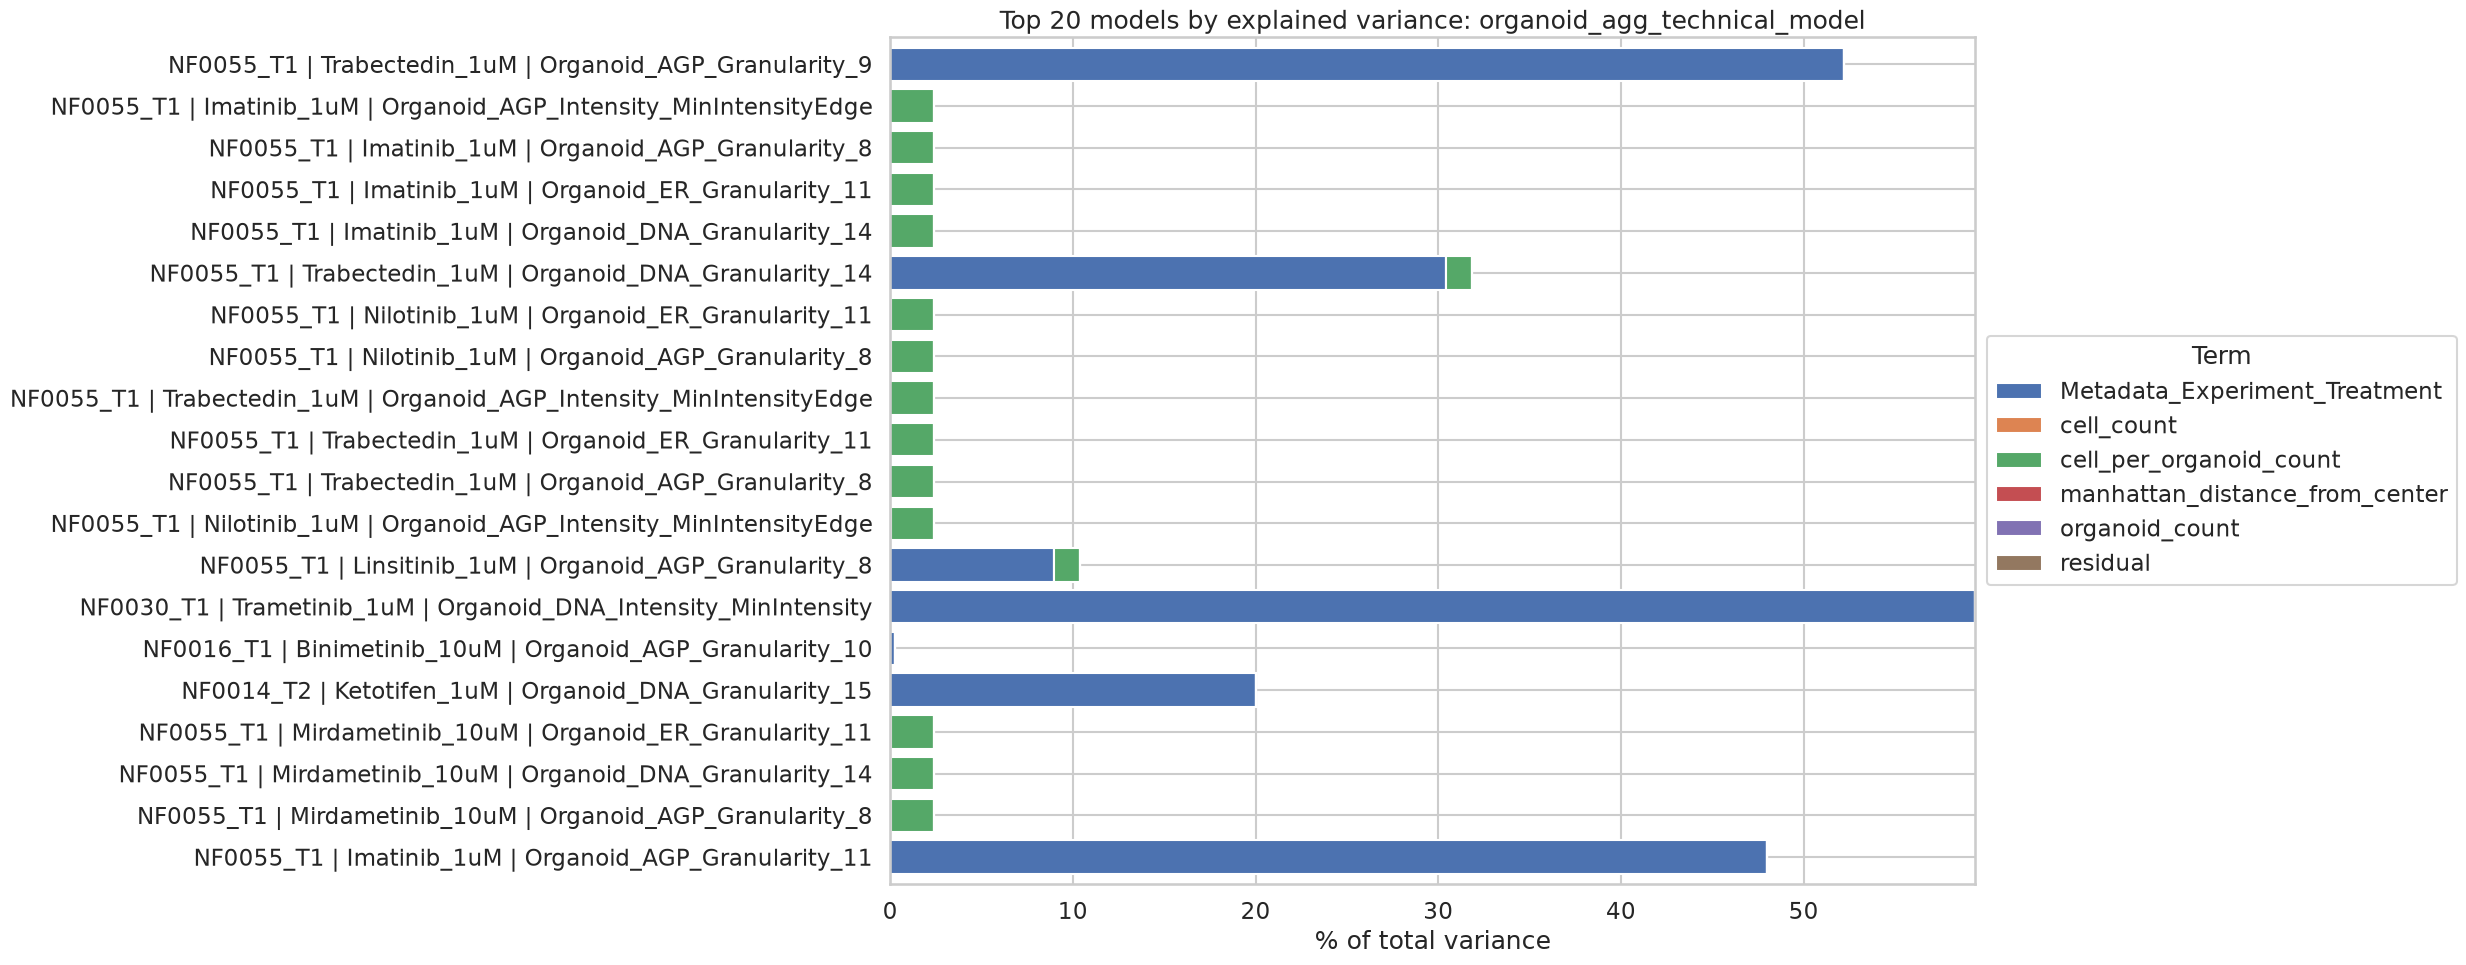

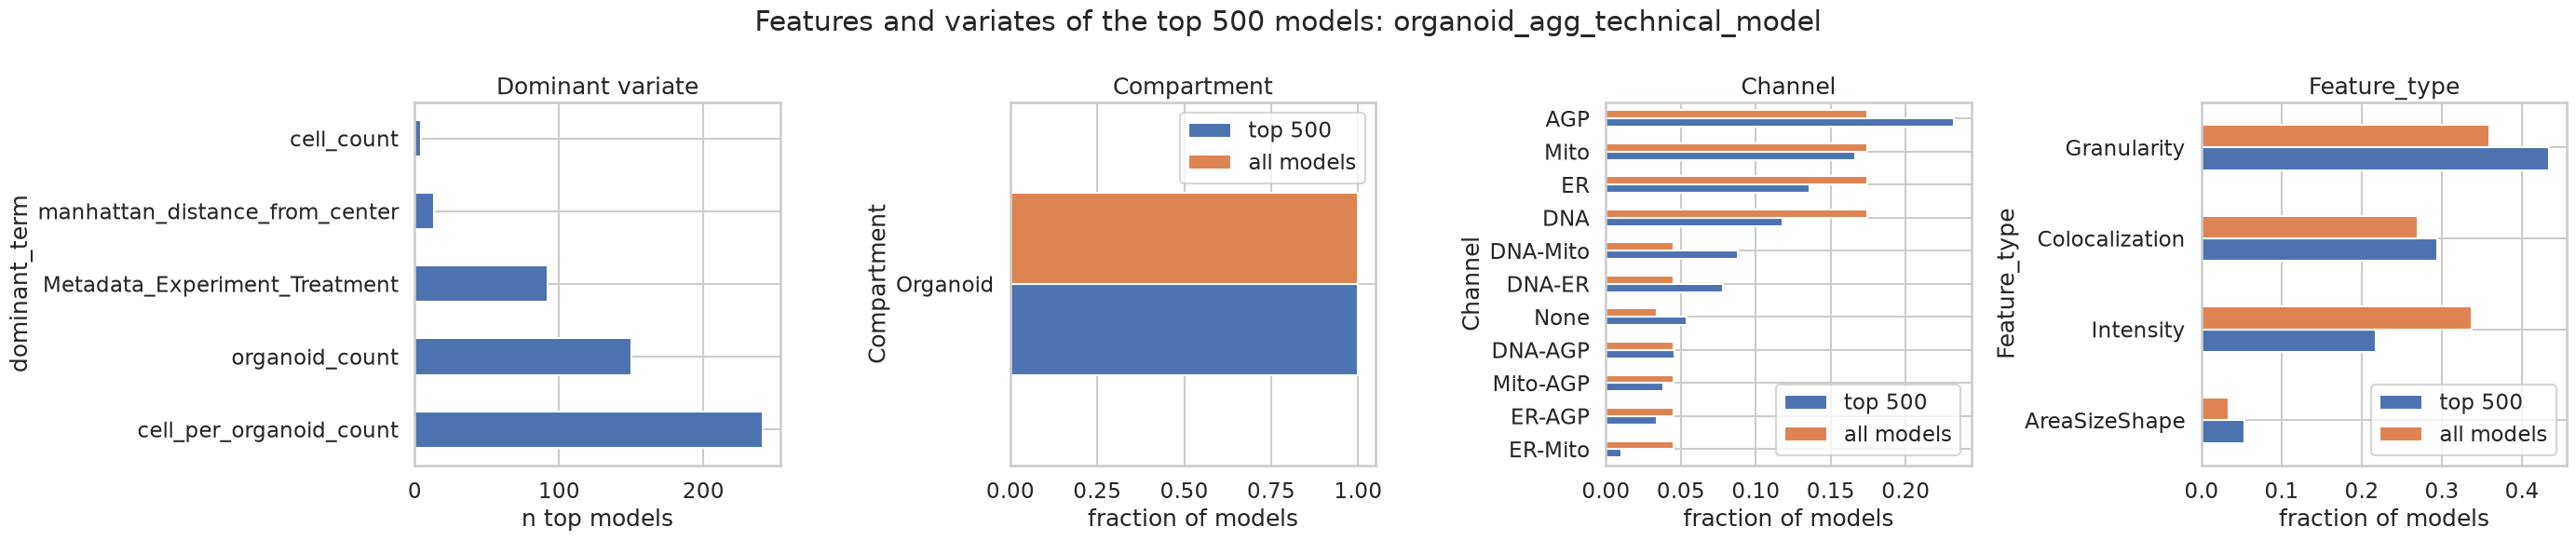

organoid_agg_technical_model
  patient         treatment                      feature                 dominant_term  residual_pct
NF0055_T1 Mirdametinib_10uM Organoid_Mito_Granularity_11 Metadata_Experiment_Treatment  2.085890e-28
NF0055_T1   Binimetinib_1uM   Organoid_ER_Granularity_10       cell_per_organoid_count  2.470760e-02
NF0055_T1   Binimetinib_1uM Organoid_Mito_Granularity_14       cell_per_organoid_count  2.470760e-02
NF0055_T1      Imatinib_1uM Organoid_Mito_Granularity_14       cell_per_organoid_count  1.842779e-27
NF0055_T1      Imatinib_1uM   Organoid_ER_Granularity_10       cell_per_organoid_count  1.842779e-27
NF0055_T1     Onalespib_1uM Organoid_Mito_Granularity_14       cell_per_organoid_count  1.608375e-27
NF0055_T1     Onalespib_1uM   Organoid_ER_Granularity_10       cell_per_organoid_count  1.608375e-27
NF0055_T1    Linsitinib_1uM Organoid_Mito_Granularity_14       cell_per_organoid_count  1.572312e-27
NF0055_T1    Linsitinib_1uM   Organoid_ER_Granularity_10      

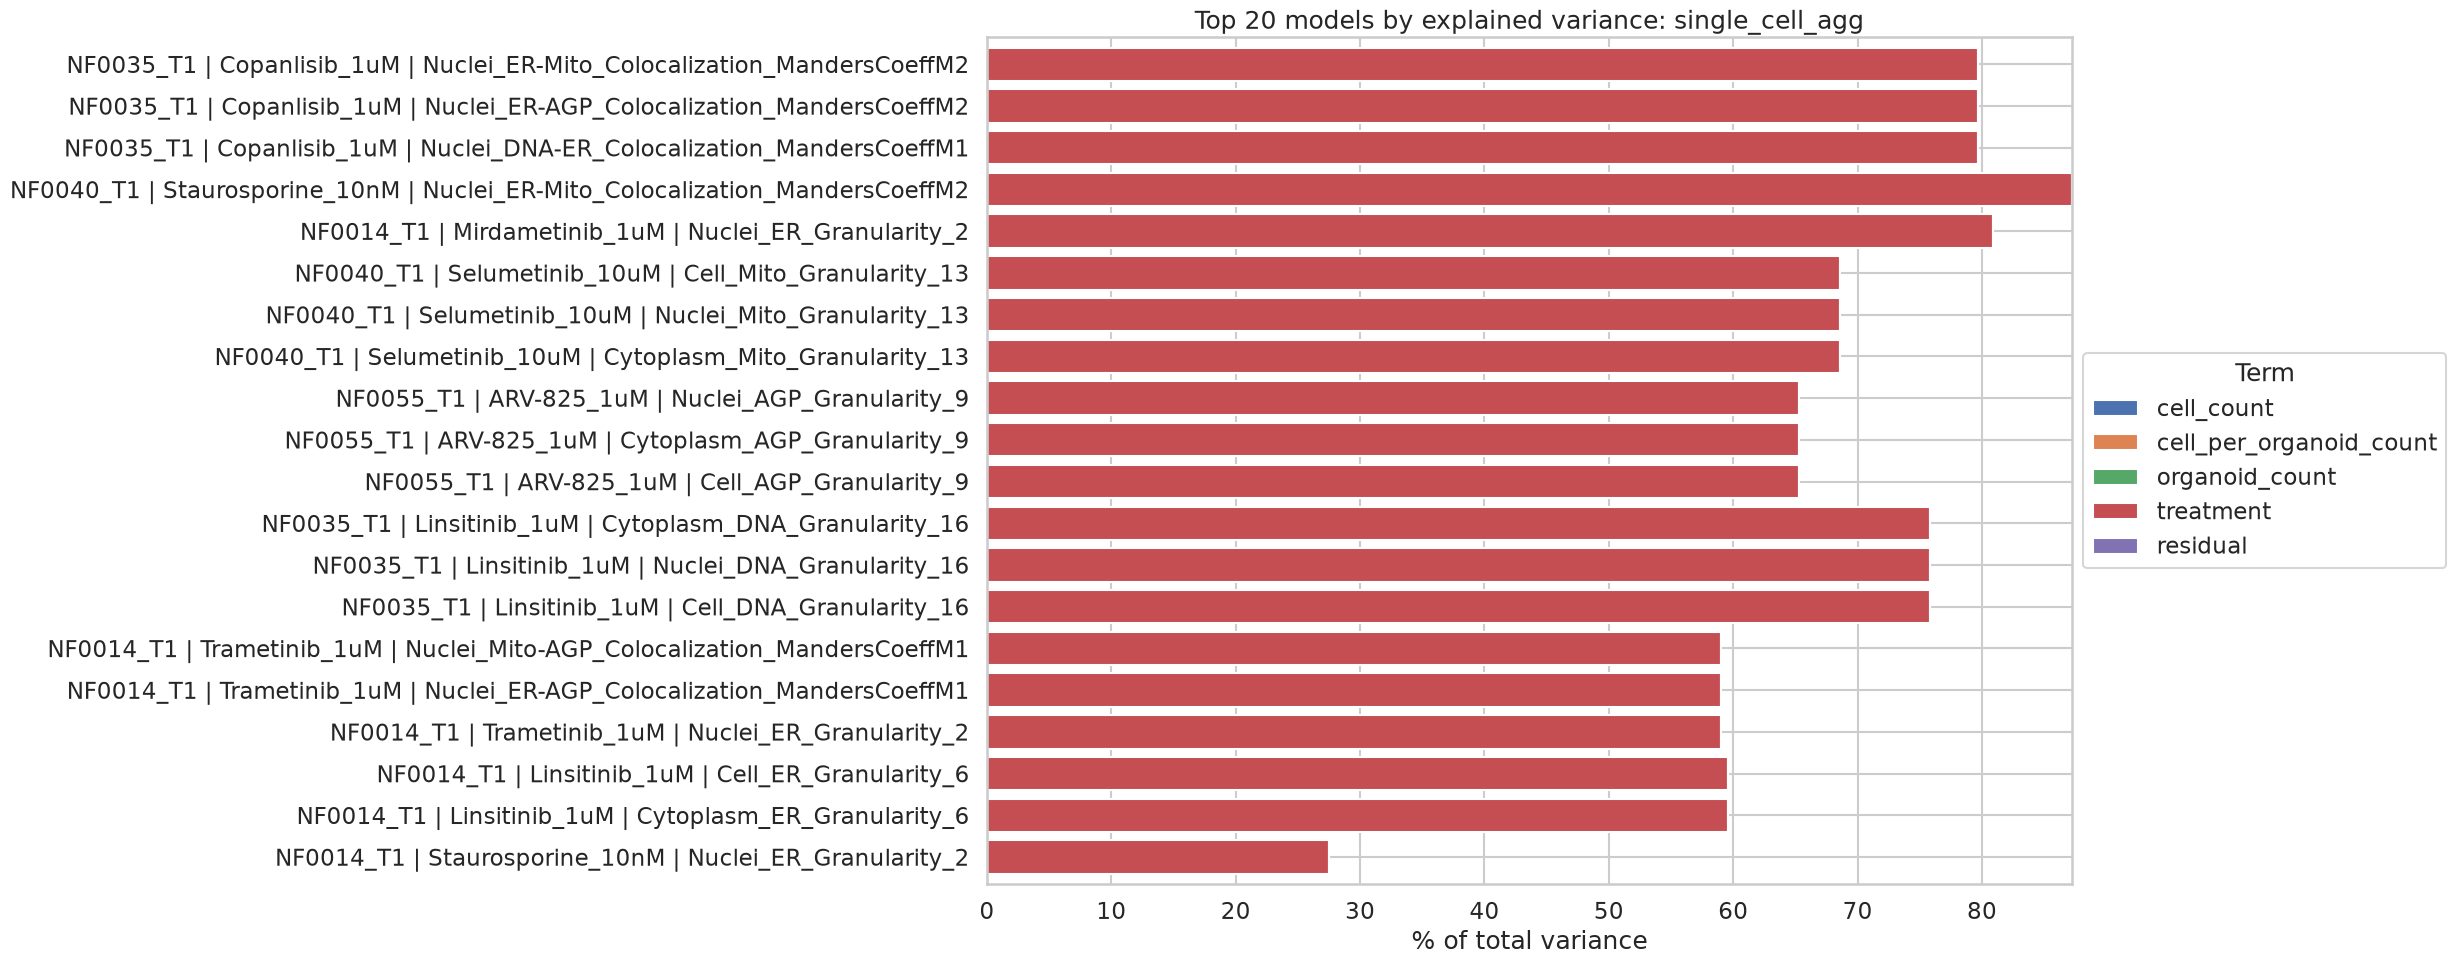

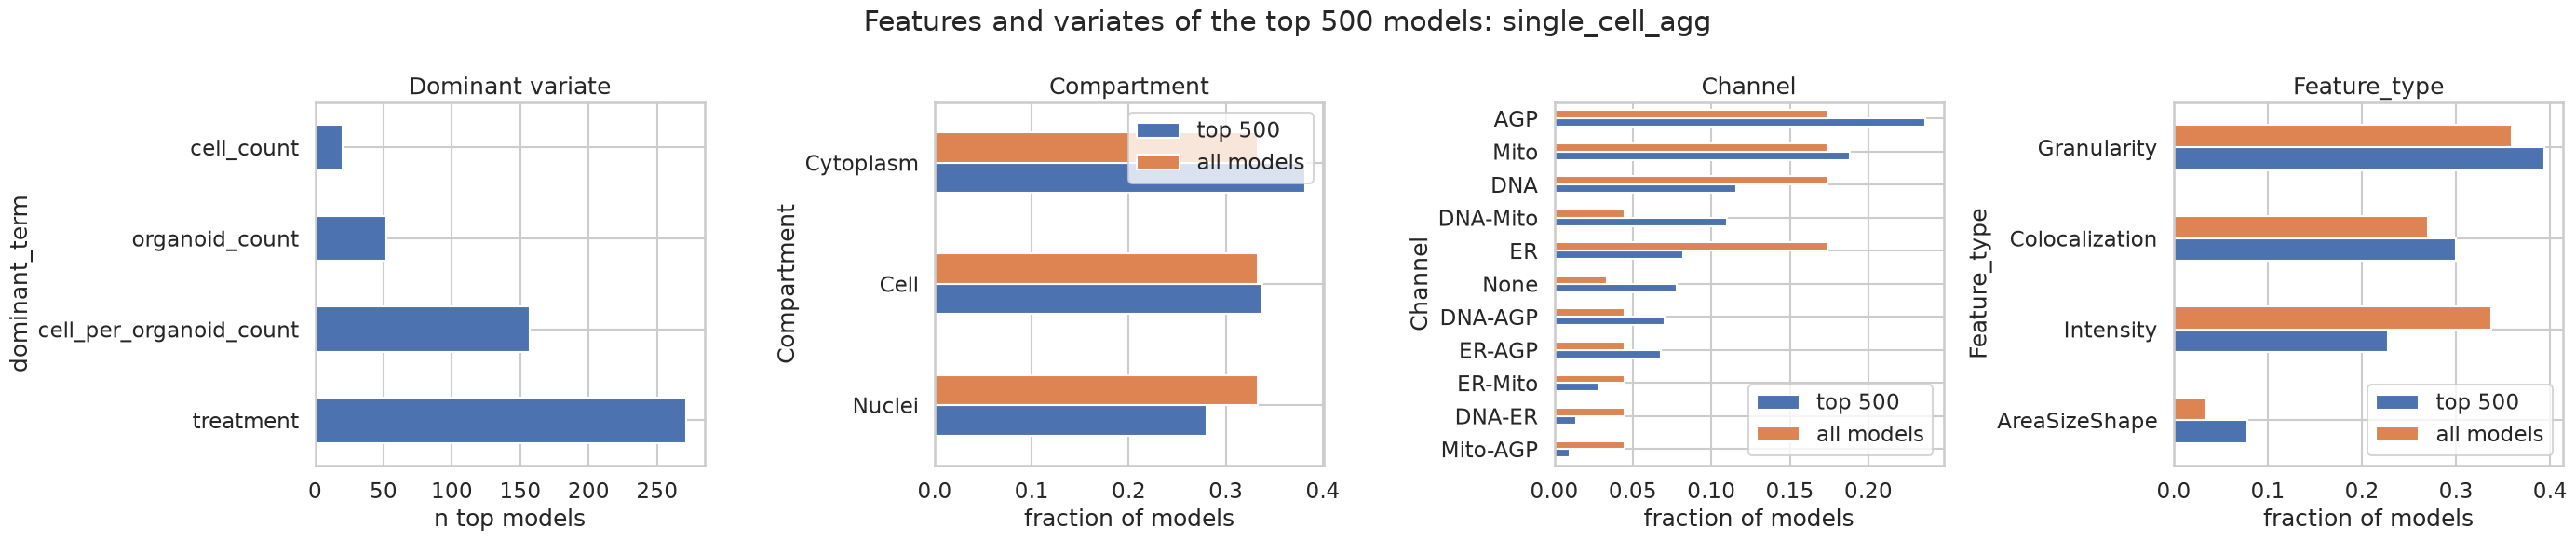

single_cell_agg
  patient       treatment                                      feature dominant_term  residual_pct
NF0016_T1 Selumetinib_1uM                       Cell_AGP_Granularity_7     treatment  2.836014e-28
NF0016_T1 Selumetinib_1uM                     Nuclei_AGP_Granularity_7     treatment  2.836014e-28
NF0016_T1 Selumetinib_1uM                Cytoplasm_Mito_Granularity_10     treatment  2.836014e-28
NF0016_T1 Selumetinib_1uM                     Cell_Mito_Granularity_10     treatment  2.836014e-28
NF0016_T1 Selumetinib_1uM                   Nuclei_Mito_Granularity_10     treatment  2.836014e-28
NF0016_T1 Selumetinib_1uM                  Cytoplasm_AGP_Granularity_7     treatment  2.836014e-28
NF0021_T1 Trametinib_10uM                   Nuclei_Mito_Granularity_16     treatment  5.783883e-01
NF0021_T1 Trametinib_10uM                Cytoplasm_Mito_Granularity_16     treatment  5.783883e-01
NF0021_T1 Trametinib_10uM                     Cell_Mito_Granularity_16     treatment  5.78388

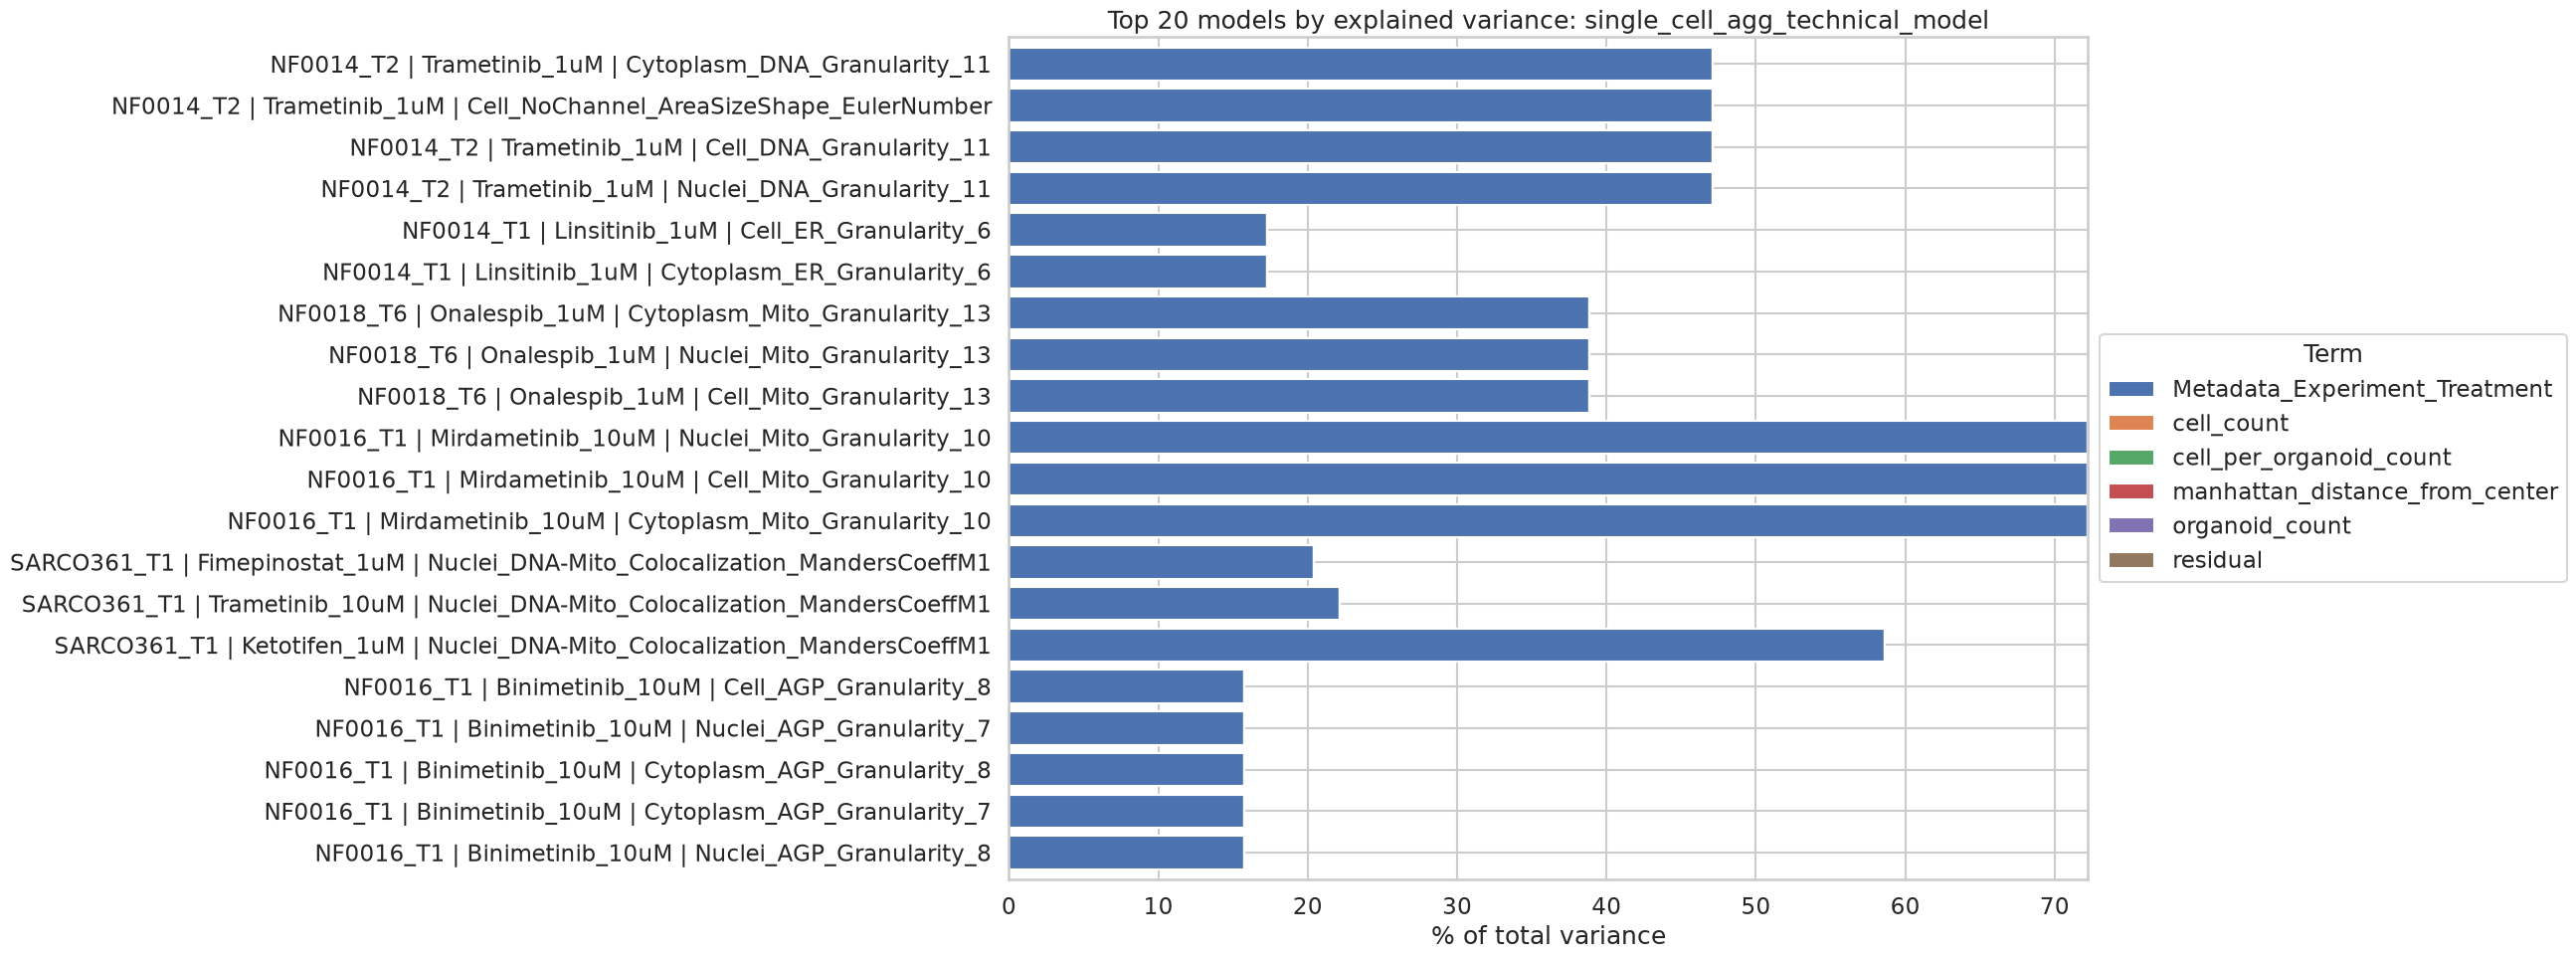

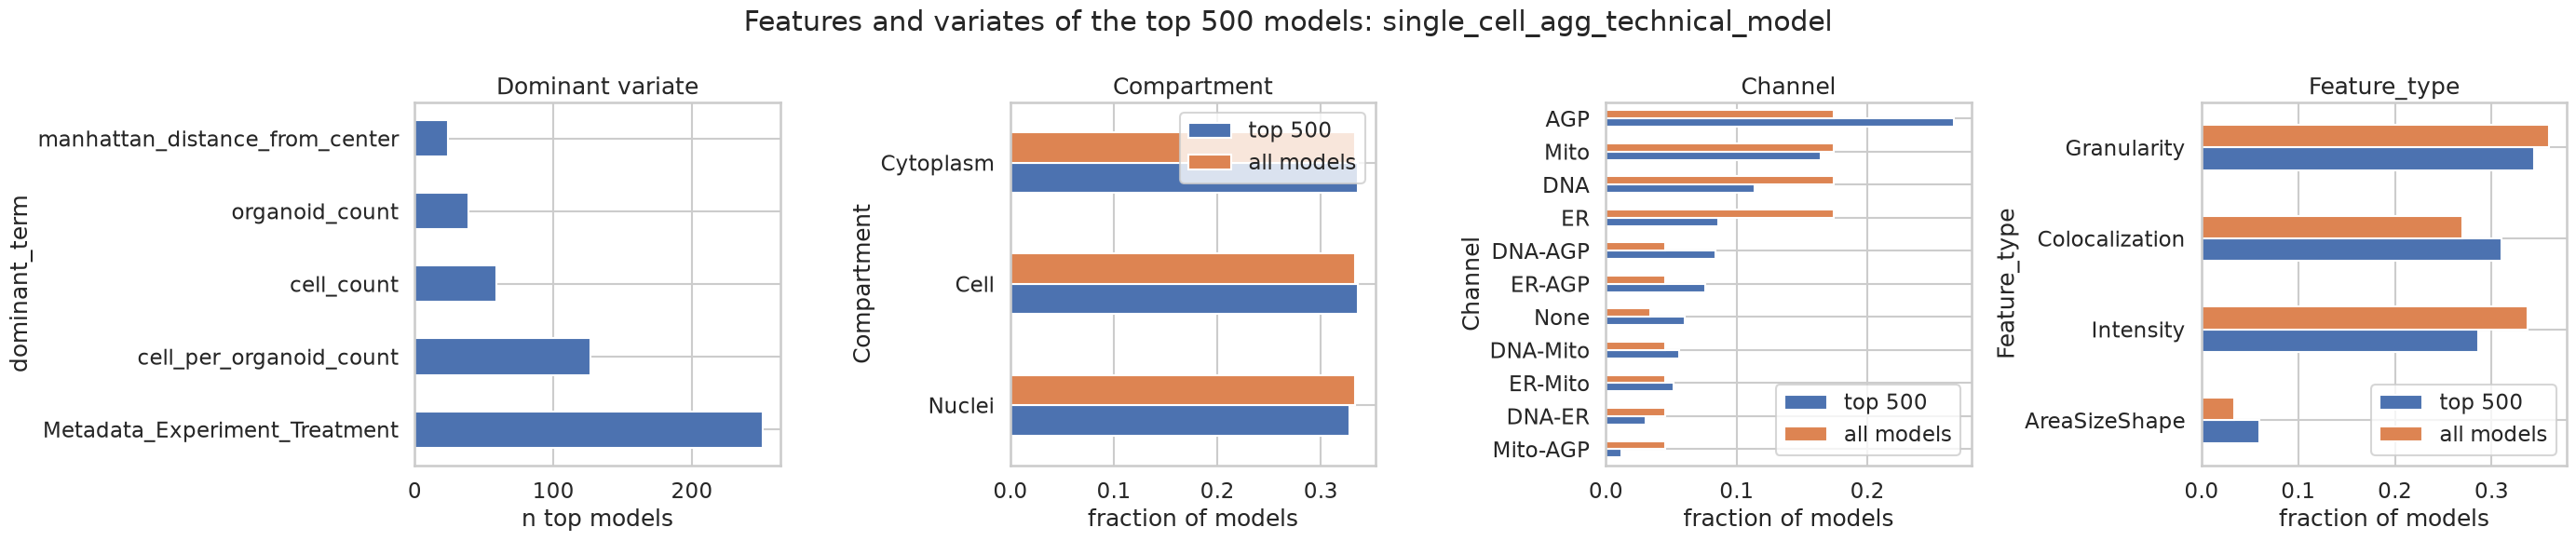

single_cell_agg_technical_model
  patient         treatment                                      feature                 dominant_term  residual_pct
NF0035_T1   Binimetinib_1uM           Cell_DNA_Intensity_MedianIntensity       cell_per_organoid_count  2.863824e-01
NF0018_T6  Binimetinib_10uM Nuclei_ER-Mito_Colocalization_MandersCoeffM2 Metadata_Experiment_Treatment  2.110659e-01
NF0018_T6  Binimetinib_10uM  Nuclei_DNA-ER_Colocalization_MandersCoeffM1 Metadata_Experiment_Treatment  2.110659e-01
NF0018_T6  Binimetinib_10uM  Nuclei_ER-AGP_Colocalization_MandersCoeffM2 Metadata_Experiment_Treatment  2.110659e-01
NF0016_T1 Mirdametinib_10uM                Cytoplasm_Mito_Granularity_10 Metadata_Experiment_Treatment  3.171120e-29
NF0016_T1 Mirdametinib_10uM                     Cell_Mito_Granularity_10 Metadata_Experiment_Treatment  3.171120e-29
NF0016_T1 Mirdametinib_10uM                   Nuclei_Mito_Granularity_10 Metadata_Experiment_Treatment  3.171120e-29
NF0035_T1    Everolimus_1uM     

In [7]:
TOP_N_PLOT = 20  # models drawn as stacked bars
TOP_N_SUMMARY = 500  # models used to count dominant variates / feature families
family_cols = ["Compartment", "Channel", "Feature_type"]

for lm_name, lm_dict in lm_results_dict.items():
    if not lm_dict["input_profile_path"].exists():
        print(f"skipping {lm_name}: {lm_dict['input_profile_path']} not found")
        continue
    df = pd.read_parquet(lm_dict["input_profile_path"]).rename(columns=rename_map)
    df["model_id"] = df["patient"] + " | " + df["treatment"] + " | " + df["feature"]
    df[family_cols] = df[family_cols].fillna("None")

    # one row per model, ranked by explained variance (100 - residual_pct)
    models_df = df.drop_duplicates("model_id").sort_values("residual_pct")
    top_ids = models_df["model_id"].head(TOP_N_SUMMARY)
    top_df = df.loc[df["model_id"].isin(top_ids)]
    top_df.to_parquet(top_dir / f"{lm_name}_top_models.parquet", index=False)

    # 1. stacked variance decomposition of the very best models
    plot_ids = list(top_ids.head(TOP_N_PLOT))
    stacked = (
        top_df.loc[top_df["model_id"].isin(plot_ids)]
        .pivot(index="model_id", columns="term", values="term_pct_of_total_var")
        .loc[plot_ids]
    )
    stacked["residual"] = models_df.set_index("model_id").loc[plot_ids, "residual_pct"]
    fig, ax = plt.subplots(figsize=(14, 0.45 * TOP_N_PLOT + 2))
    stacked.plot(kind="barh", stacked=True, ax=ax, width=0.8)
    ax.invert_yaxis()
    ax.set_xlabel("% of total variance")
    ax.set_ylabel("")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), title="Term")
    fig.tight_layout()
    pdfs.savefig(fig, figures_path / "variance_decomposition.pdf")
    plt.show()

    # 2 + 3. which variate dominates each top model, and which feature
    # families the top models come from (share of the top set vs. all models)
    dominant = (
        top_df.sort_values("term_pct_of_total_var", ascending=False)
        .drop_duplicates("model_id")
        .rename(columns={"term": "dominant_term"})
    )
    fig, axes = plt.subplots(1, 4, figsize=(28, 6))
    dominant["dominant_term"].value_counts().plot(kind="barh", ax=axes[0])
    axes[0].set_xlabel("n top models")
    for ax, col in zip(axes[1:], family_cols):
        share = pd.DataFrame(
            {
                f"top {TOP_N_SUMMARY}": dominant[col].value_counts(normalize=True),
                "all models": models_df[col].value_counts(normalize=True),
            }
        ).fillna(0)
        share.sort_values(f"top {TOP_N_SUMMARY}").plot(kind="barh", ax=ax)
        ax.set_xlabel("fraction of models")
    fig.tight_layout()
    pdfs.savefig(fig, figures_path / "variance_decomposition.pdf")
    plt.show()

    print(lm_name)
    print(
        dominant[["patient", "treatment", "feature", "dominant_term", "residual_pct"]]
        .head(10)
        .to_string(index=False)
    )

In [ ]:
pdfs.close()